# Exploratory Data Analysis — Vidio Play Events

Dataset: `bigquery-rahmalianto.practice.vidio_test_raw`

Analysis structure:

1. Data Overview — Schema, row count, sample data, missing values
2. Temporal Analysis — Play volume over time, hourly and daily patterns
3. Platform & Device Analysis — Platform distribution, OS, browser breakdown
4. Content Analysis — Content types, stream types, top categories, premium vs. free
5. Engagement Analysis — Play duration, completion rates, bitrate range
6. Referrer & Traffic Analysis — Referrer groups, playback locations, UTM source presence
7. Top Content — Most-watched titles and sinetron genres
8. User Behavior & Frequency Segmentation — Dynamic quantiles of watcher frequency
9. Sessionization & Journey Analysis — Session summary metrics and plays per session
10. Autoplay & Ad Engagement Impact (Bounce Analysis) — Bounce plays and Autoplay/Ad impact
11. App/Device Specific Performance Heatmap — Performance heatmap by app and OS version
12. Summary & Actionable Recommendations

In [136]:
# Setup & imports
import bigframes
import bigframes.pandas as bpd
%load_ext bigframes

# Configure BigFrames display options to show up to 50 rows
bigframes.options.display.max_rows = 50

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plotting defaults
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'
sns.set_theme(style='whitegrid', palette='muted')

PROJECT = 'bigquery-rahmalianto'
DATASET = 'practice'
TABLE = 'vidio_test_raw'
FQN = f'{PROJECT}.{DATASET}.{TABLE}'

print(f'Target table: {FQN}')

The bigframes extension is already loaded. To reload it, use:
  %reload_ext bigframes
Target table: bigquery-rahmalianto.practice.vidio_test_raw


## 1. Data Overview

* **Key Findings:** The dataset contains **7,127,357 play events** spanning from **Feb 1, 2020** to **Feb 16, 2020**. Around **22.9%** (1.63M) of plays are by logged-in users, while the remaining **77.1%** (5.49M) are anonymous.

In [137]:
%%bqsql df_overview
SELECT
  COUNT(*) AS total_rows,
  COUNT(DISTINCT hash_content_id) AS unique_content,
  COUNT(DISTINCT hash_play_uuid) AS unique_plays,
  COUNT(DISTINCT hash_watcher_id) AS unique_watchers,
  MIN(play_time) AS earliest_play,
  MAX(play_time) AS latest_play,
  COUNTIF(is_login = true) AS logged_in_plays,
  COUNTIF(is_login = false) AS anonymous_plays,
  COUNTIF(is_login = true)/COUNT(*) as login_pct
FROM `bigquery-rahmalianto.practice.vidio_test_raw`

,total_rows,unique_content,unique_plays,unique_watchers,earliest_play,latest_play,logged_in_plays,anonymous_plays,login_pct
0,7127357,104940,7122165,4316481,2020-02-01 09:01:42+00:00,2020-02-16 16:59:59+00:00,1632507,5494850,0.229048


In [138]:
%%bqsql df_sample
SELECT *
FROM `bigquery-rahmalianto.practice.vidio_test_raw`
LIMIT 5

,hash_content_id,hash_play_uuid,hash_visit_id,hash_watcher_id,hash_film_id,hash_event_id,is_login,playback_location,platform,play_time,...,app_version,city,play_duration,content_type,stream_type,title,category_name,film_title,season_name,genre_name
0,e17048119e86c59f66498e4fc2a28278b109a3a1128a4d...,1521f68c0bb4973878806a9eb0e3b7092881d40983843f...,ab97739262a7b63ce1a1dbf2314bd62bce1fb7230d01ed...,bbab540dfe2e787836aa7ec8026ed7265635a2d76bb6ae...,<NA>,295a63c2129e542cb157c572f2bedab739e1e8874eab5f...,True,direct,tv-android,2020-02-08 19:38:13+00:00,...,1.16.2 (74),<NA>,0,livestreaming,TvStream,OShop,<NA>,<NA>,<NA>,<NA>
1,3da6ee6699da1eb52d358aa59b8e1cf6b5d77db224b4ce...,eebfe285deb40a63e41c17c7020631e8ef751f56f21b95...,420c0b0bc7a36c9af5dd9fcdeeb1200aa916b22d6ea4aa...,0f5a5710438a9ae1bdd89c4def0c8098e3c410f34189ce...,<NA>,ad4d53d321086fe6476ff3fa38474fd86060c35582d050...,False,direct,tv-webos,2020-02-14 16:57:41+00:00,...,<NA>,<NA>,0,livestreaming,TvStream,ANTV,<NA>,<NA>,<NA>,<NA>
2,fc56dbc6d4652b315b86b71c8d688c1ccdea9c5f1fd077...,f78dc0f9f113f715476ed6a2f706f5688ddb9408d38266...,262a32171c80d0b91d4307c06333330f9eeed84f69df44...,508be574f30db7fad7715ed5cd52b90f9214b0e2e1c43c...,<NA>,ee18ce808e9466b9dc1244834a7e82fb7e17ba62d35368...,True,direct,tv-tizen,2020-02-15 08:25:01+00:00,...,1.8.3,<NA>,0,livestreaming,TvStream,SCTV,<NA>,<NA>,<NA>,<NA>
3,9ae8f17cfc8ba7fd8fb34b2a194ef965a3b36a40839a46...,541ce6a9259b70327f26c4680fb5bda1e5717d3d4a8d5c...,ccbecb915431d27788da278d2455e19fecf9235628921d...,238939e956b49a2f59bb925a7aeedb6b65c5faa675966e...,<NA>,9f05593d72792883fff9bd39f00e3b5285171969070357...,False,direct,tv-android,2020-02-10 04:02:42+00:00,...,1.15.1 (68),<NA>,0,livestreaming,TvStream,RCTI,<NA>,<NA>,<NA>,<NA>
4,93411f44e228b5004bdec50f32b6c646819eebd09ba3fa...,09b26b2ca14b30f58aa3dd51cda3c0b2ed0cb99c567282...,daf1f7724e751e1a5a2df616e4795f0595a1d8f967f9f2...,93e9f6445461bc95ea01b44fcf10b5ac2aea37826f5613...,<NA>,81aaa332cdec4320c356cab72982be58dee7a7872a462c...,False,direct,tv-android,2020-02-04 10:47:34+00:00,...,1.15.1 (68),<NA>,0,livestreaming,TvStream,GTV,<NA>,<NA>,<NA>,<NA>


### Missing Values Analysis

* **Key Findings:** Location (`city`) is almost entirely missing (**99.99%** null). Marketing campaign attributions (`utm_source`/`medium`/`campaign`) are also heavily under-tracked (**~99%** null). Film-specific columns (`film_title`, `season_name`, `genre_name`) are null for **~94.5%** of plays, as expected since film content only represents a small fraction of overall plays.

In [139]:
%%bqsql df_nulls
SELECT
  COUNT(*) AS total_rows,
  COUNTIF(hash_content_id IS NULL) AS null_content_id,
  COUNTIF(hash_play_uuid IS NULL) AS null_play_uuid,
  COUNTIF(hash_visit_id IS NULL) AS null_visit_id,
  COUNTIF(hash_watcher_id IS NULL) AS null_watcher_id,
  COUNTIF(hash_film_id IS NULL OR hash_film_id = '') AS null_film_id,
  COUNTIF(hash_event_id IS NULL OR hash_event_id = '') AS null_event_id,
  COUNTIF(is_login IS NULL) AS null_is_login,
  COUNTIF(playback_location IS NULL OR playback_location = '') AS null_playback_location,
  COUNTIF(platform IS NULL OR platform = '') AS null_platform,
  COUNTIF(play_time IS NULL) AS null_play_time,
  COUNTIF(end_time IS NULL) AS null_end_time,
  COUNTIF(referrer IS NULL OR referrer = '') AS null_referrer,
  COUNTIF(average_bitrate IS NULL) AS null_average_bitrate,
  COUNTIF(bitrate_range IS NULL OR bitrate_range = '') AS null_bitrate_range,
  COUNTIF(total_bytes IS NULL) AS null_total_bytes,
  COUNTIF(buffer_duration IS NULL) AS null_buffer_duration,
  COUNTIF(referrer_group IS NULL OR referrer_group = '') AS null_referrer_group,
  COUNTIF(completed IS NULL) AS null_completed,
  COUNTIF(utm_source IS NULL OR utm_source = '') AS null_utm_source,
  COUNTIF(utm_medium IS NULL OR utm_medium = '') AS null_utm_medium,
  COUNTIF(utm_campaign IS NULL OR utm_campaign = '') AS null_utm_campaign,
  COUNTIF(player_name IS NULL OR player_name = '') AS null_player_name,
  COUNTIF(has_ad IS NULL) AS null_has_ad,
  COUNTIF(flash_version IS NULL OR flash_version = '') AS null_flash_version,
  COUNTIF(os_name IS NULL OR os_name = '') AS null_os_name,
  COUNTIF(os_version IS NULL OR os_version = '') AS null_os_version,
  COUNTIF(browser_name IS NULL OR browser_name = '') AS null_browser_name,
  COUNTIF(browser_version IS NULL OR browser_version = '') AS null_browser_version,
  COUNTIF(app_name IS NULL OR app_name = '') AS null_app_name,
  COUNTIF(autoplay IS NULL) AS null_autoplay,
  COUNTIF(is_premium IS NULL) AS null_is_premium,
  COUNTIF(app_version IS NULL OR app_version = '') AS null_app_version,
  COUNTIF(city IS NULL OR city = '') AS null_city,
  COUNTIF(play_duration IS NULL) AS null_play_duration,
  COUNTIF(content_type IS NULL OR content_type = '') AS null_content_type,
  COUNTIF(stream_type IS NULL OR stream_type = '') AS null_stream_type,
  COUNTIF(title IS NULL OR title = '') AS null_title,
  COUNTIF(category_name IS NULL OR category_name = '') AS null_category_name,
  COUNTIF(film_title IS NULL OR film_title = '') AS null_film_title,
  COUNTIF(season_name IS NULL OR season_name = '') AS null_season_name,
  COUNTIF(genre_name IS NULL OR genre_name = '') AS null_genre_name
FROM `bigquery-rahmalianto.practice.vidio_test_raw`


,total_rows,null_content_id,null_play_uuid,null_visit_id,null_watcher_id,null_film_id,null_event_id,null_is_login,null_playback_location,null_platform,...,null_app_version,null_city,null_play_duration,null_content_type,null_stream_type,null_title,null_category_name,null_film_title,null_season_name,null_genre_name
0,7127357,0,0,0,0,6738898,0,0,0,0,...,4806905,7127220,137,0,4527673,1,2599635,6738270,6738849,6778362


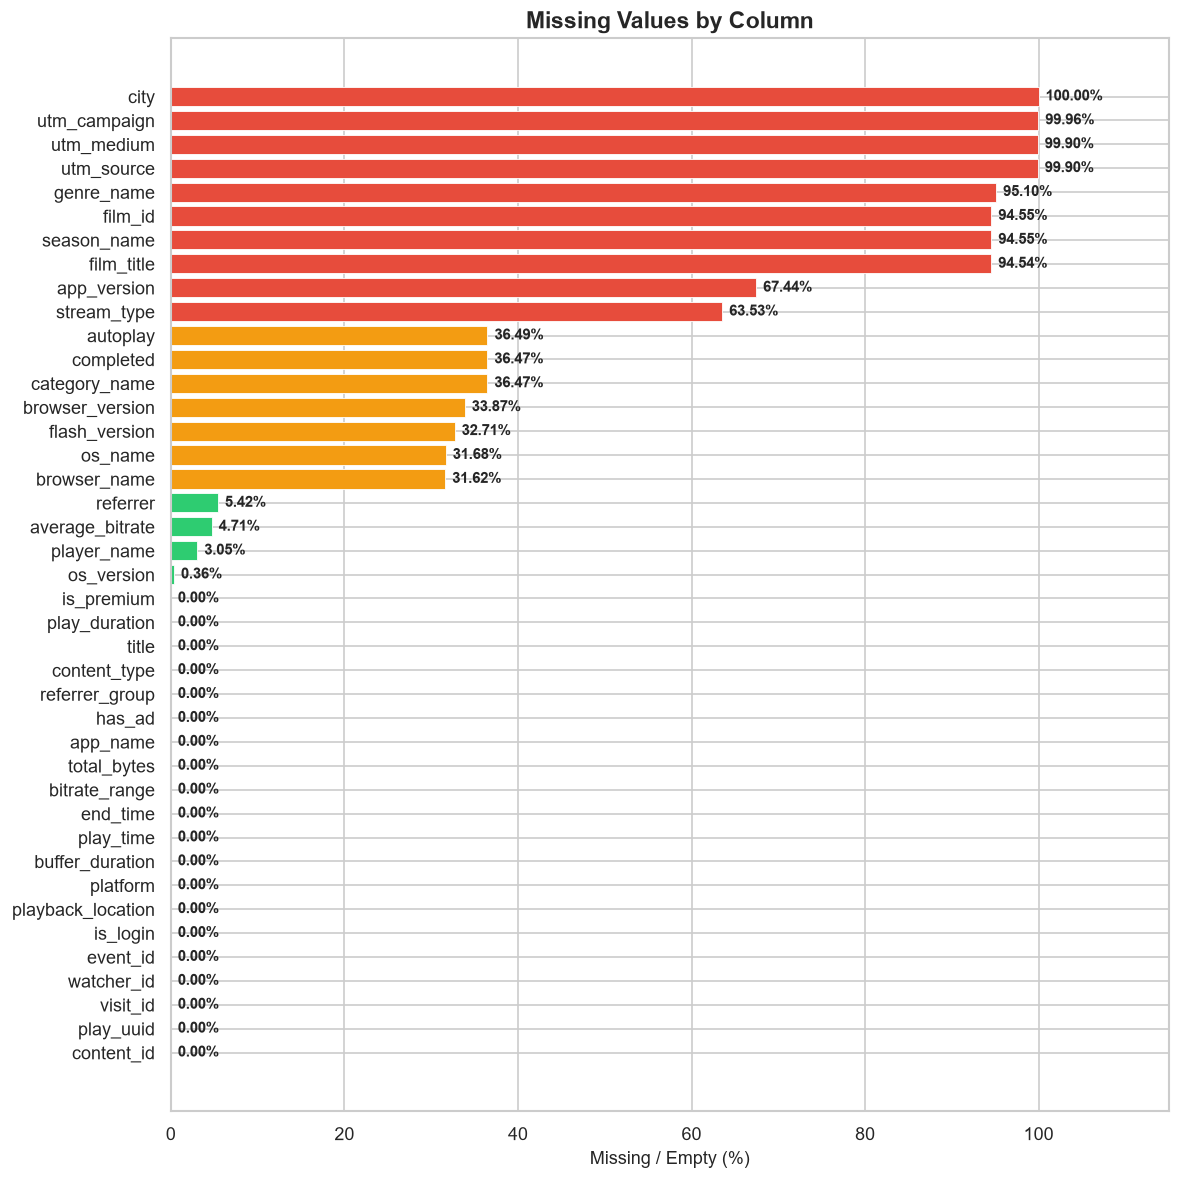

In [178]:
# Visualize missing values as a horizontal bar chart
import pandas as pd

nulls_pd = df_nulls.to_pandas()
total = nulls_pd['total_rows'].iloc[0]

# Build a series of null counts (exclude total_rows)
null_cols = [c for c in nulls_pd.columns if c.startswith('null_')]
null_data = {c.replace('null_', ''): nulls_pd[c].iloc[0] for c in null_cols}
null_series = pd.Series(null_data).sort_values(ascending=True)
null_pct = (null_series / total * 100).round(2)

fig, ax = plt.subplots(figsize=(10, 10))
colors = ['#e74c3c' if v > 50 else '#f39c12' if v > 20 else '#2ecc71' for v in null_pct.values]
bars = ax.barh(null_pct.index, null_pct.values, color=colors, edgecolor='white', linewidth=0.5)

for bar, pct in zip(bars, null_pct.values):
    ax.text(bar.get_width() + 0.8, bar.get_y() + bar.get_height()/2,
            f'{pct:.2f}%', va='center', fontsize=9, fontweight='bold')

ax.set_xlabel('Missing / Empty (%)', fontsize=11)
ax.set_title('Missing Values by Column', fontsize=14, fontweight='bold')
ax.set_xlim(0, max(null_pct.values) * 1.15 if max(null_pct.values) > 0 else 10)
plt.tight_layout()
plt.show()

## 2. Temporal Analysis

* **Key Findings:** Play volume peaks on **Wednesday, Feb 12, 2020** with **549,220 plays** and **456,292 unique watchers**. Daily plays map extremely closely to the unique watcher count. Looking at weekly distributions, **Sunday** is the peak day with **1.29M plays**, while **Friday** has the lowest play volume (**865k plays**).

In [141]:
%%bqsql df_daily_plays
SELECT
  DATE(play_time) AS play_date,
  COUNT(*) AS play_count,
  COUNT(DISTINCT hash_watcher_id) AS unique_watchers
FROM `bigquery-rahmalianto.practice.vidio_test_raw`
WHERE play_time IS NOT NULL
GROUP BY play_date
ORDER BY play_date DESC

,play_date,play_count,unique_watchers
0,2020-02-16,408276,331698
1,2020-02-15,519666,428156
2,2020-02-14,402673,333517
3,2020-02-13,543787,455029
4,2020-02-12,549220,456292
5,2020-02-11,516062,427630
6,2020-02-10,521994,420300
7,2020-02-09,442755,351822
8,2020-02-08,425658,339472
9,2020-02-07,462914,377322


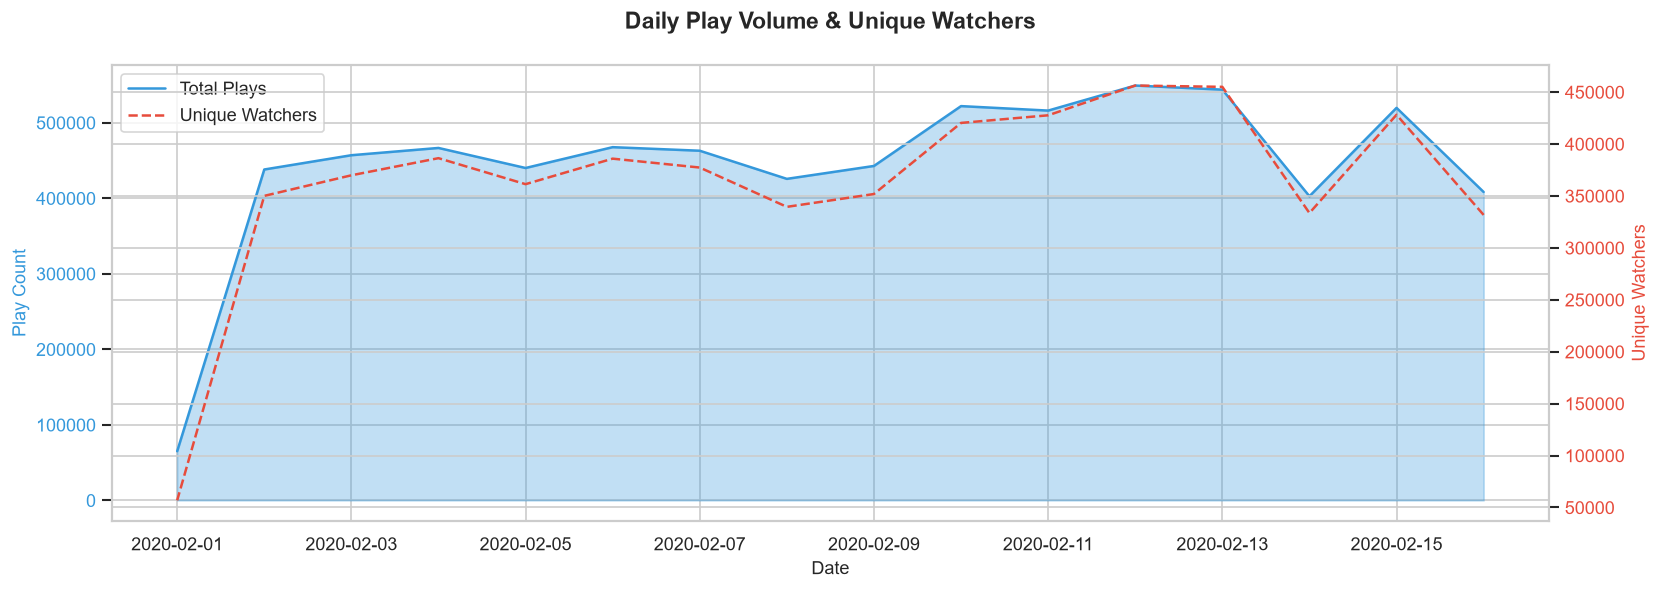

In [142]:
# Plot daily play volume
daily_pd = df_daily_plays.to_pandas()
daily_pd['play_date'] = pd.to_datetime(daily_pd['play_date'])

fig, ax1 = plt.subplots(figsize=(14, 5))
color1 = '#3498db'
color2 = '#e74c3c'

ax1.fill_between(daily_pd['play_date'], daily_pd['play_count'], alpha=0.3, color=color1)
ax1.plot(daily_pd['play_date'], daily_pd['play_count'], color=color1, linewidth=1.5, label='Total Plays')
ax1.set_xlabel('Date', fontsize=11)
ax1.set_ylabel('Play Count', color=color1, fontsize=11)
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx()
ax2.plot(daily_pd['play_date'], daily_pd['unique_watchers'], color=color2, linewidth=1.5, linestyle='--', label='Unique Watchers')
ax2.set_ylabel('Unique Watchers', color=color2, fontsize=11)
ax2.tick_params(axis='y', labelcolor=color2)

fig.suptitle('Daily Play Volume & Unique Watchers', fontsize=14, fontweight='bold')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.tight_layout()
plt.show()

In [143]:
%%bqsql df_hourly
SELECT
  EXTRACT(HOUR FROM play_time) AS hour_of_day,
  COUNT(*) AS play_count
FROM `bigquery-rahmalianto.practice.vidio_test_raw`
WHERE play_time IS NOT NULL
GROUP BY hour_of_day
ORDER BY hour_of_day

,hour_of_day,play_count
0,0,239958
1,1,280998
2,2,301385
3,3,312263
4,4,325101
5,5,331881
6,6,333880
7,7,340403
8,8,331942
9,9,353128


In [144]:
%%bqsql df_dow
SELECT
  FORMAT_TIMESTAMP('%A', play_time) AS day_of_week,
  EXTRACT(DAYOFWEEK FROM play_time) AS dow_num,
  COUNT(*) AS play_count
FROM `bigquery-rahmalianto.practice.vidio_test_raw`
WHERE play_time IS NOT NULL
GROUP BY day_of_week, dow_num
ORDER BY dow_num

,day_of_week,dow_num,play_count
0,Sunday,1,1289098
1,Monday,2,978968
2,Tuesday,3,982650
3,Wednesday,4,989276
4,Thursday,5,1011424
5,Friday,6,865587
6,Saturday,7,1010354


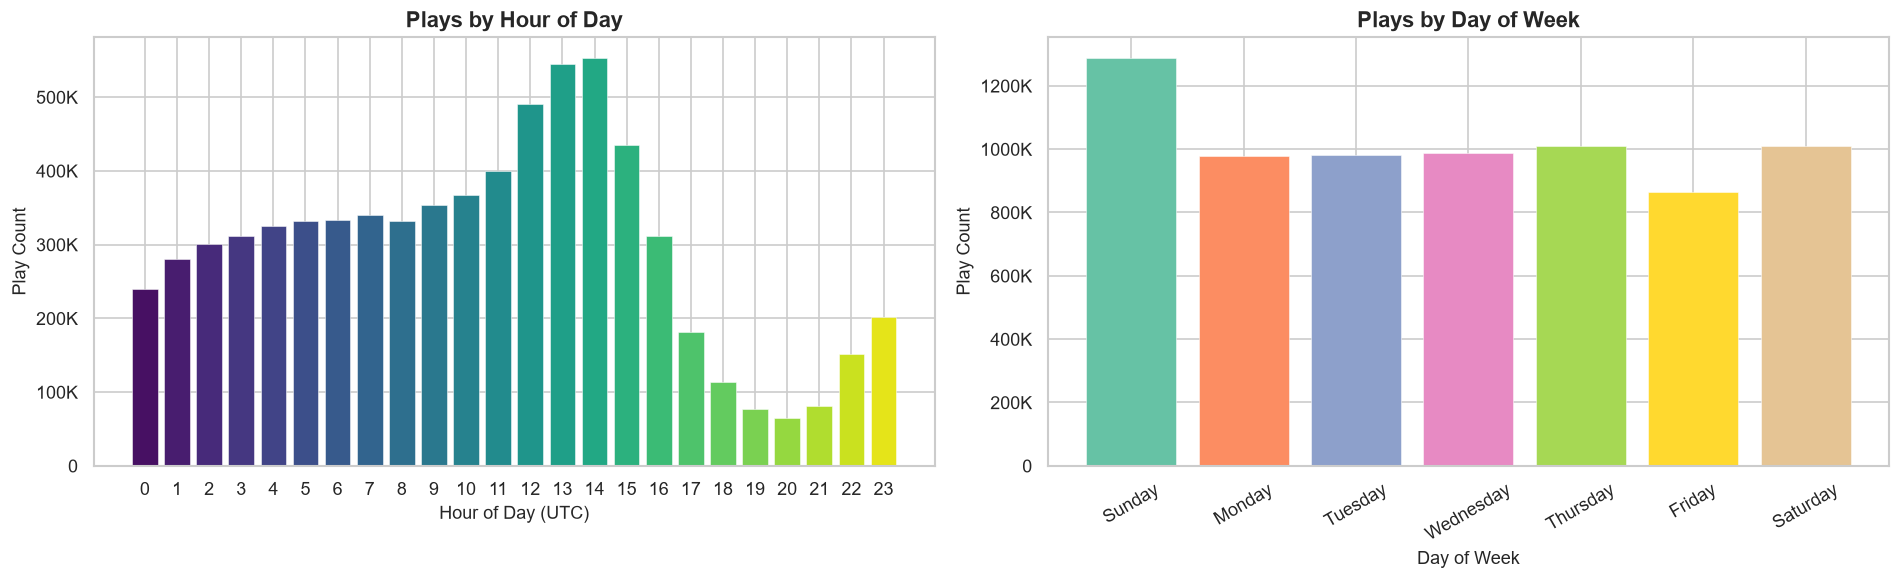

In [145]:
# Hourly and Day-of-Week distribution side by side
hourly_pd = df_hourly.to_pandas().sort_values('hour_of_day')
dow_pd = df_dow.to_pandas().sort_values('dow_num')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Hourly
colors_h = sns.color_palette('viridis', n_colors=24)
ax1.bar(hourly_pd['hour_of_day'], hourly_pd['play_count'], color=colors_h, edgecolor='white', linewidth=0.3)
ax1.set_xlabel('Hour of Day (UTC)', fontsize=11)
ax1.set_ylabel('Play Count', fontsize=11)
ax1.set_title('Plays by Hour of Day', fontsize=13, fontweight='bold')
ax1.set_xticks(range(0, 24))
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K' if x >= 1000 else f'{x:.0f}'))

# Day of week
colors_d = sns.color_palette('Set2', n_colors=7)
ax2.bar(dow_pd['day_of_week'], dow_pd['play_count'], color=colors_d, edgecolor='white', linewidth=0.3)
ax2.set_xlabel('Day of Week', fontsize=11)
ax2.set_ylabel('Play Count', fontsize=11)
ax2.set_title('Plays by Day of Week', fontsize=13, fontweight='bold')
ax2.tick_params(axis='x', rotation=30)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K' if x >= 1000 else f'{x:.0f}'))

plt.tight_layout()
plt.show()

### Temporal Analysis Insights

Based on the temporal trends, we observe three major patterns in user viewing behavior:

1. **Daily Volume & Stability:**
   * Excluding the first day (Feb 1, which has **65,030 plays** as tracking was initialized), daily play volume remains stable between **400k and 550k plays**.
   * We observe the absolute peak in traffic on **Wednesday, Feb 12**, reaching **549,220 plays** (with **456,292 unique watchers**).
   * A secondary traffic peak occurred on **Thursday, Feb 13** (reaching **543,787 plays** and **455,029 unique watchers**), while **Monday, Feb 10** also saw a significant spike of **521,994 plays** (and **420,300 unique watchers**).
   * Play volume and unique watcher count track in near-perfect lockstep daily, highlighting consistent play frequency per watcher day-over-day.

2. **Hourly Habits (UTC vs. WIB):**
   * The hourly peak occurs between **UTC 12 and UTC 15** (which corresponds to **7 PM to 10 PM WIB** / Western Indonesian Time), with the absolute peak hour at **UTC 14** (9 PM WIB) reaching **553,590 plays**. This matches typical post-work/evening prime-time entertainment viewing hours in Indonesia.
   * The lowest viewing period is between **UTC 19 and UTC 21** (**2 AM to 4 AM WIB**), representing the late-night/early morning dip (minimum at UTC 20 / 3 AM WIB with **65,256 plays**).

3. **Weekly Distribution:**
   * **Sunday** is the dominant viewing day of the week with **1,289,098 plays** (~18.1% of total plays), showing high leisure-time engagement.
   * **Thursday** (**1,011,424 plays**) and **Saturday** (**1,010,354 plays**) are also strong traffic drivers.
   * **Friday** has the lowest play volume of the week at **865,587 plays**, showing a temporary weekend-eve dip.

## 3. Platform & Device Analysis

* **Key Findings:** **Mobile-web** is the dominant platform, driving **57.65%** (4.11M) of plays, followed by **Android app** at **24.39%** (1.74M) and **desktop-web** at **9.64%** (687k). Similarly, **Android OS** accounts for **54.2%** of all plays, while **31.7%** are reported from unknown operating systems.

In [146]:
%%bqsql df_platform
SELECT
  platform,
  COUNT(*) AS play_count,
  ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) AS pct
FROM `bigquery-rahmalianto.practice.vidio_test_raw`
GROUP BY platform
ORDER BY play_count DESC

,platform,play_count,pct
0,web-mobile,4109015,57.65
1,app-android,1738714,24.39
2,web-desktop,686736,9.64
3,tv-android,395031,5.54
4,app-ios,119894,1.68
5,tv-tizen,67456,0.95
6,tv-webos,10511,0.15


In [147]:
%%bqsql df_os
SELECT
  IFNULL(NULLIF(os_name, ''), 'Unknown') AS os_name,
  COUNT(*) AS play_count
FROM `bigquery-rahmalianto.practice.vidio_test_raw`
GROUP BY os_name
ORDER BY play_count DESC
LIMIT 10

,os_name,play_count
0,Android,3859928
1,Unknown,2257772
2,Windows,635374
3,iOS,254846
4,REL,73833
5,Mac OS X,28947
6,Linux,10333
7,Tizen,2410
8,Ubuntu,1513
9,Other,1149


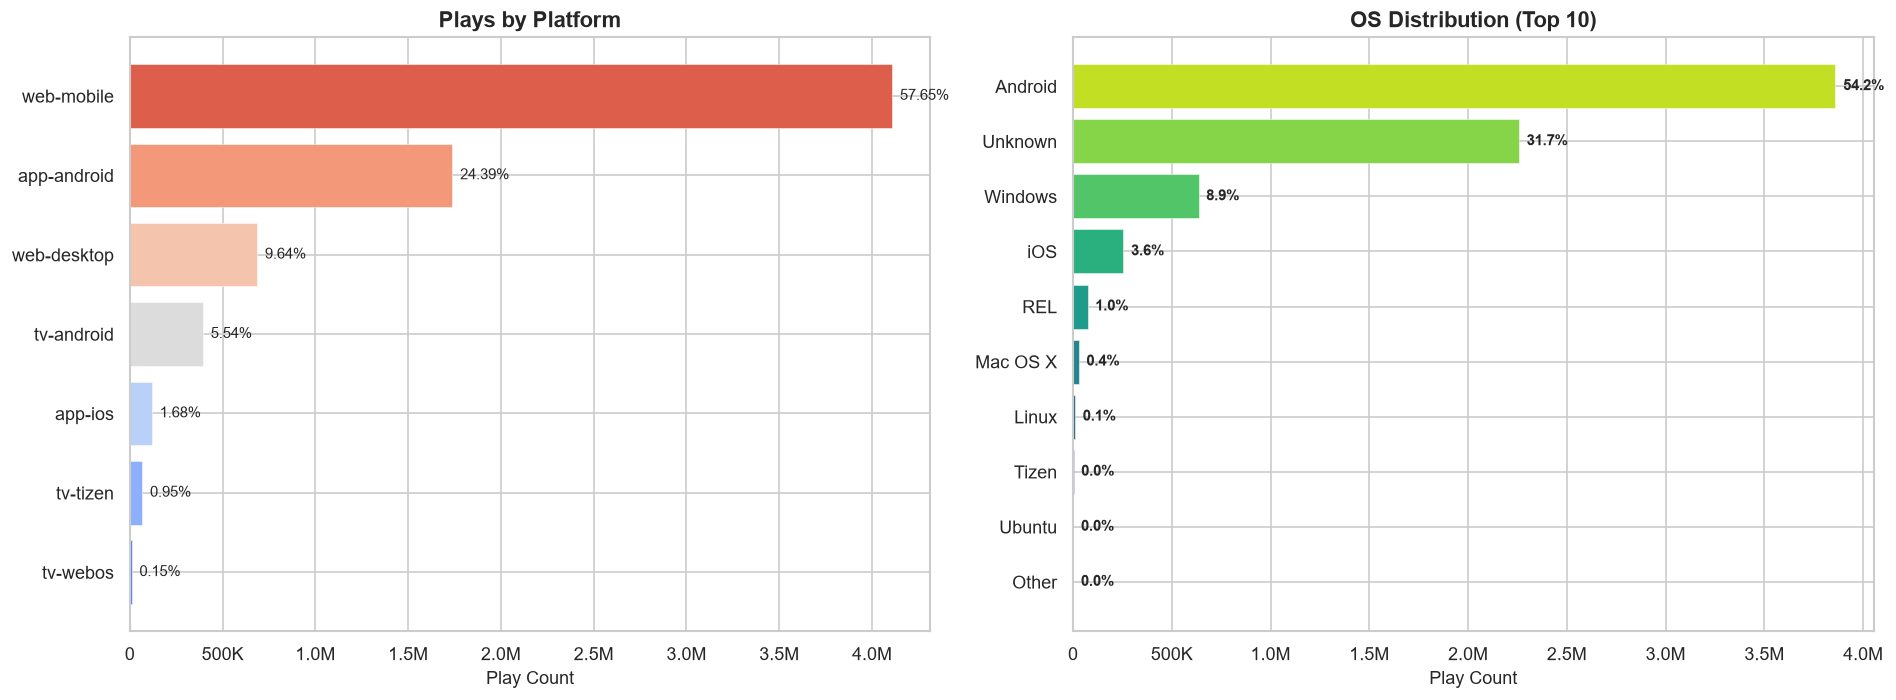

In [148]:
# Platform and OS distribution charts
platform_pd = df_platform.to_pandas()
os_pd = df_os.to_pandas()

# Convert to standard types to avoid NAType issues
platform_pd['play_count'] = platform_pd['play_count'].astype(float)
platform_pd['pct'] = platform_pd['pct'].astype(float)
os_pd['play_count'] = os_pd['play_count'].astype(float)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Platform - horizontal bar
colors_p = sns.color_palette('coolwarm', n_colors=len(platform_pd))
ax1.barh(platform_pd['platform'][::-1], platform_pd['play_count'][::-1],
         color=colors_p, edgecolor='white', linewidth=0.3)
for i, (v, pct) in enumerate(zip(platform_pd['play_count'][::-1], platform_pd['pct'][::-1])):
    ax1.text(v + max(platform_pd['play_count'])*0.01, i, f'{pct}%', va='center', fontsize=9)
ax1.set_xlabel('Play Count', fontsize=11)
ax1.set_title('Plays by Platform', fontsize=13, fontweight='bold')
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}K' if x >= 1e3 else f'{x:.0f}'))

# OS - horizontal bar chart
colors_os = sns.color_palette('viridis', n_colors=len(os_pd))
ax2.barh(os_pd['os_name'][::-1], os_pd['play_count'][::-1],
         color=colors_os, edgecolor='white', linewidth=0.3)
ax2.set_title('OS Distribution (Top 10)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Play Count', fontsize=11)
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}K' if x >= 1e3 else f'{x:.0f}'))

# Add percentage labels on the right of the bars
total_os_plays = os_pd['play_count'].sum()
for i, (v, name) in enumerate(zip(os_pd['play_count'][::-1], os_pd['os_name'][::-1])):
    if total_os_plays > 0:
        pct = (v / total_os_plays) * 100
        ax2.text(v + max(os_pd['play_count'])*0.01, i, f'{pct:.1f}%', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

## 4. Content Analysis

* **Key Findings:**
  * **Content Type Distribution:** **VOD** (Video-On-Demand) is the most popular content type with **4.50M plays** (**63.1%** of total), though with a relatively short average duration of **245.0s** and a **24.67%** completion rate. **Livestreaming** is the second largest driver with **2.60M plays** (**36.5%** of total), but commands much higher average watch times of **733.7s** (completion rate is N/A for live streams). **Catchup** represents a tiny fraction of traffic (**27,150 plays**, **0.4%**) but has the longest average duration of **1,805.2s** (though a low **11.28%** completion rate).
  * **Stream Type Breakdown:** Within livestreaming, **TvStream** is the dominant stream type with **2.54M plays** (**97.7%** of live traffic), while **EventStream** accounts for **58,514 plays** (**2.3%**).
  * **Top Categories:** Excluding livestreaming (which is categorized as `N/A` in this field with **2.60M** occurrences), the top VOD/catchup genres are **Entertainment** (**1.47M plays**, **32.4%** of categorized plays) and **News** (**1.41M plays**, **31.1%**), followed by **Sports** (**520k plays**, **11.5%**) and **Movies** (**385k plays**, **8.5%**).

In [149]:
%%bqsql df_content_type
SELECT
  content_type,
  COUNT(*) AS play_count,
  COUNTIF(is_premium = true) AS premium_plays,
  COUNTIF(is_premium = false) AS free_plays,
  ROUND(AVG(play_duration), 1) AS avg_duration_sec,
  ROUND(COUNTIF(completed = true) * 100.0 / NULLIF(COUNTIF(completed IS NOT NULL), 0), 2) AS completion_rate_pct
FROM `bigquery-rahmalianto.practice.vidio_test_raw`
WHERE content_type IN ('vod', 'livestreaming', 'catchup')
GROUP BY content_type
ORDER BY play_count DESC

,content_type,play_count,premium_plays,free_plays,avg_duration_sec,completion_rate_pct
0,vod,4500522,32924,4467598,245.0,24.67
1,livestreaming,2599548,28774,2570773,733.7,<NA>
2,catchup,27150,0,27150,1805.2,11.28


In [150]:
%%bqsql df_stream_type
SELECT
  IFNULL(NULLIF(stream_type, ''), 'N/A (VOD)') AS stream_type,
  COUNT(*) AS play_count
FROM `bigquery-rahmalianto.practice.vidio_test_raw`
WHERE stream_type IN ('N/A (VOD)', 'TvStream', 'EventStream')
GROUP BY stream_type
ORDER BY play_count DESC

,stream_type,play_count
0,TvStream,2541033
1,EventStream,58514


In [151]:
%%bqsql df_top_categories
SELECT
  IFNULL(NULLIF(category_name, ''), 'N/A') AS category_name,
  COUNT(*) AS play_count
FROM `bigquery-rahmalianto.practice.vidio_test_raw`
GROUP BY category_name
ORDER BY play_count DESC
LIMIT 15

,category_name,play_count
0,N/A,2599635
1,Entertainment,1469291
2,News,1408689
3,Sports,520445
4,Movies,384978
5,TV Show,290602
6,Music,160657
7,Vlog,114405
8,Lifestyle,91306
9,Funny,30967


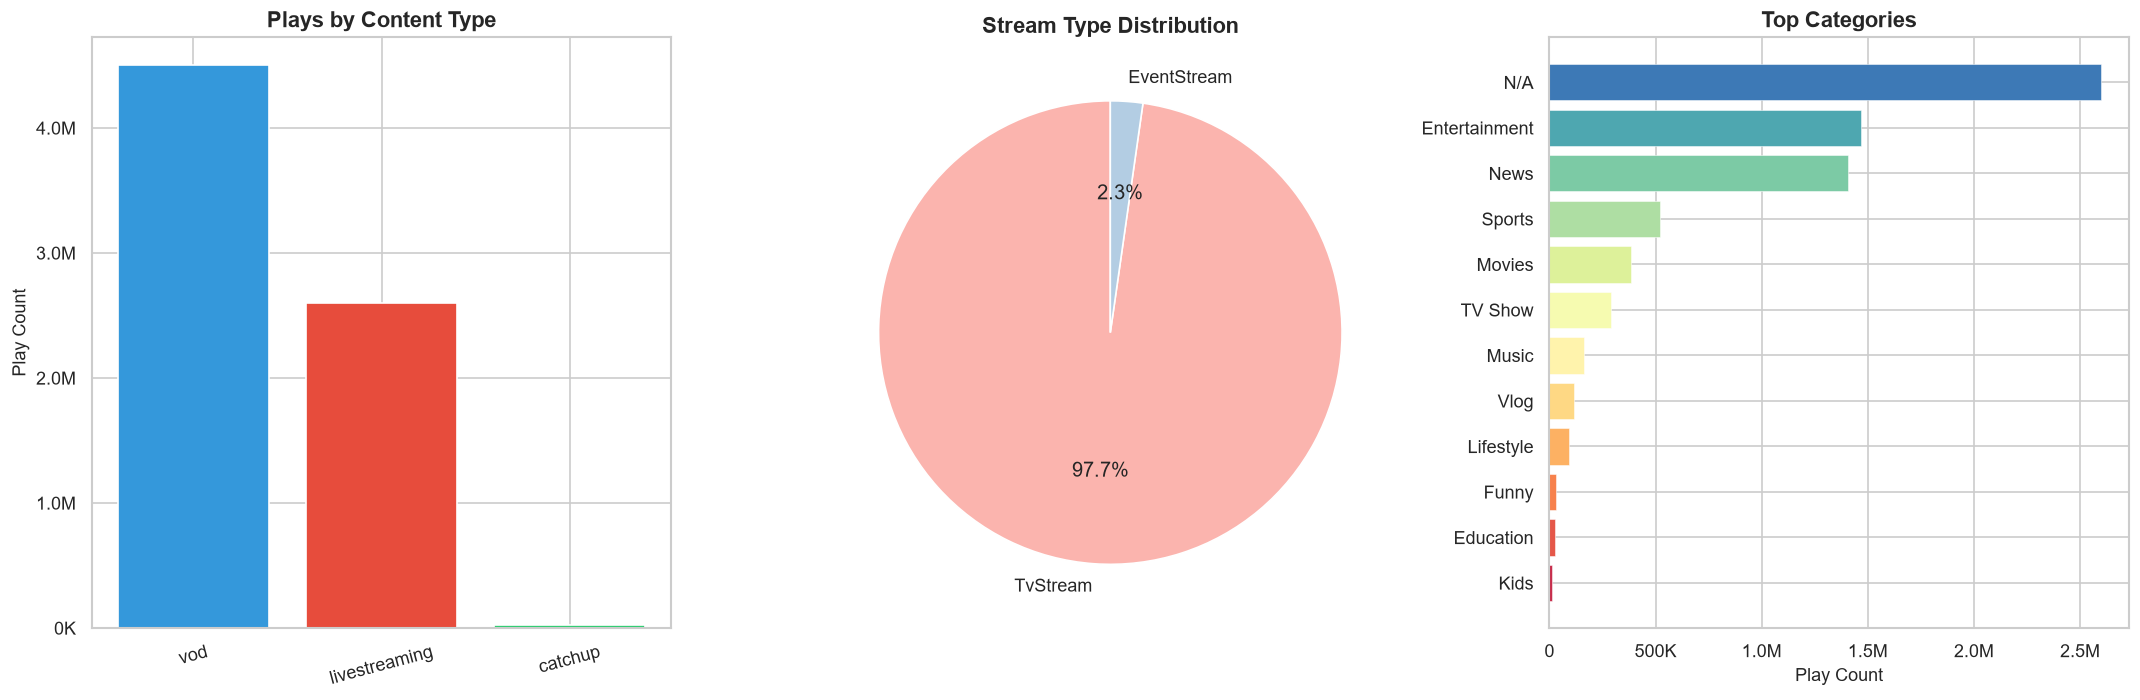

In [152]:
# Content type, stream type, and top categories charts
content_pd = df_content_type.to_pandas()
stream_pd = df_stream_type.to_pandas()
cat_pd = df_top_categories.to_pandas()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Content type bar
colors_ct = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
axes[0].bar(content_pd['content_type'], content_pd['play_count'],
            color=colors_ct[:len(content_pd)], edgecolor='white')
axes[0].set_title('Plays by Content Type', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Play Count', fontsize=11)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}K'))
axes[0].tick_params(axis='x', rotation=15)

# Stream type pie
colors_st = sns.color_palette('Pastel1', n_colors=len(stream_pd))
axes[1].pie(stream_pd['play_count'], labels=stream_pd['stream_type'],
            autopct='%1.1f%%', colors=colors_st, startangle=90)
axes[1].set_title('Stream Type Distribution', fontsize=13, fontweight='bold')

# Top categories horizontal bar
cat_plot = cat_pd.head(12).sort_values('play_count')
colors_cat = sns.color_palette('Spectral', n_colors=len(cat_plot))
axes[2].barh(cat_plot['category_name'], cat_plot['play_count'],
             color=colors_cat, edgecolor='white', linewidth=0.3)
axes[2].set_title('Top Categories', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Play Count', fontsize=11)
axes[2].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}K' if x >= 1e3 else f'{x:.0f}'))

plt.tight_layout()
plt.show()

### Premium vs. Free Content

* **Key Findings:**
  * **Dominance of Free Tier:** **99.1%** of all play events (**7.07M plays**) are on the **Free tier**, which attracts **4.30M unique watchers** (avg duration: **420.7s**, completion rate: **24.52%**). Free plays are heavily anonymous (**77.8%** of free plays are anonymous / not logged in).
  * **Premium Tier Engagement:** **Premium content** accounts for only **0.9%** (**61,698 plays**) across **28,585 unique watchers**, but drives dramatically higher user engagement. The average play duration for Premium content is **1,404.7s** (over 3x higher than Free) with a **33.13%** completion rate (vs **24.52%** for Free).
  * **Login Status on Premium:** Almost all Premium plays are by logged-in users (**98.1%** or **60,499 plays**), as expected since premium content access requires authentication and subscription. Only **1,199 plays** on premium content were by anonymous users (likely trailers or promotional preview windows).

In [153]:
%%bqsql df_premium
SELECT
  CASE WHEN is_premium THEN 'Premium' ELSE 'Free' END AS content_tier,
  COUNT(*) AS play_count,
  COUNT(DISTINCT hash_watcher_id) AS unique_watchers,
  ROUND(AVG(play_duration), 1) AS avg_duration_sec,
  ROUND(COUNTIF(completed = true) * 100.0 / NULLIF(COUNTIF(completed IS NOT NULL), 0), 2) AS completion_rate_pct,
  COUNTIF(is_login = true) AS logged_in,
  COUNTIF(is_login = false) AS anonymous
FROM `bigquery-rahmalianto.practice.vidio_test_raw`
GROUP BY content_tier

,content_tier,play_count,unique_watchers,avg_duration_sec,completion_rate_pct,logged_in,anonymous
0,Free,7065659,4301470,420.7,24.52,1572008,5493651
1,Premium,61698,28585,1404.7,33.13,60499,1199


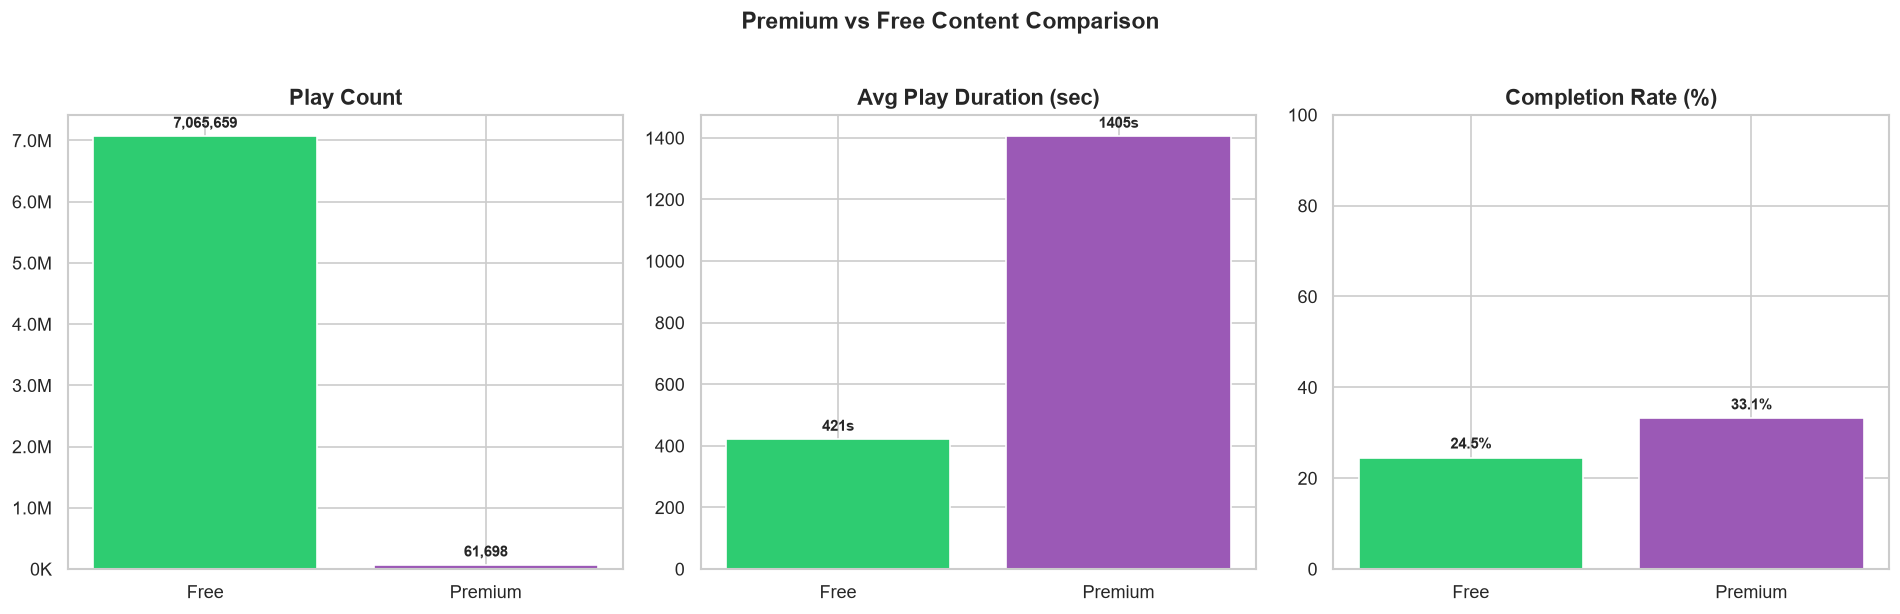

In [154]:
# Premium vs Free comparison
prem_pd = df_premium.to_pandas()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors_prem = ['#2ecc71', '#9b59b6']

# Play count
axes[0].bar(prem_pd['content_tier'], prem_pd['play_count'], color=colors_prem, edgecolor='white')
axes[0].set_title('Play Count', fontsize=13, fontweight='bold')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}K'))
for i, v in enumerate(prem_pd['play_count']):
    axes[0].text(i, v + max(prem_pd['play_count'])*0.02, f'{v:,.0f}', ha='center', fontsize=9, fontweight='bold')

# Avg duration
axes[1].bar(prem_pd['content_tier'], prem_pd['avg_duration_sec'], color=colors_prem, edgecolor='white')
axes[1].set_title('Avg Play Duration (sec)', fontsize=13, fontweight='bold')
for i, v in enumerate(prem_pd['avg_duration_sec']):
    axes[1].text(i, v + max(prem_pd['avg_duration_sec'])*0.02, f'{v:.0f}s', ha='center', fontsize=9, fontweight='bold')

# Completion rate
axes[2].bar(prem_pd['content_tier'], prem_pd['completion_rate_pct'], color=colors_prem, edgecolor='white')
axes[2].set_title('Completion Rate (%)', fontsize=13, fontweight='bold')
axes[2].set_ylim(0, 100)
for i, v in enumerate(prem_pd['completion_rate_pct']):
    axes[2].text(i, v + 2, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Premium vs Free Content Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 5. Engagement Analysis

* **Key Findings:** Play duration is heavily skewed towards short view times, with **29.4%** of plays lasting less than 10 seconds, and over **63%** under 1 minute. Platform completion rates are led by **Android app** (**31.82%**), while mobile-web has a completion rate of **23.44%**.

In [155]:
%%bqsql df_duration_dist
SELECT
  CASE
    WHEN play_duration <= 10 THEN '0-10s'
    WHEN play_duration <= 30 THEN '11-30s'
    WHEN play_duration <= 60 THEN '31-60s'
    WHEN play_duration <= 300 THEN '1-5min'
    WHEN play_duration <= 900 THEN '5-15min'
    WHEN play_duration <= 1800 THEN '15-30min'
    WHEN play_duration <= 3600 THEN '30-60min'
    ELSE '60min+'
  END AS duration_bucket,
  CASE
    WHEN play_duration <= 10 THEN 1
    WHEN play_duration <= 30 THEN 2
    WHEN play_duration <= 60 THEN 3
    WHEN play_duration <= 300 THEN 4
    WHEN play_duration <= 900 THEN 5
    WHEN play_duration <= 1800 THEN 6
    WHEN play_duration <= 3600 THEN 7
    ELSE 8
  END AS bucket_order,
  COUNT(*) AS play_count
FROM `bigquery-rahmalianto.practice.vidio_test_raw`
GROUP BY duration_bucket, bucket_order
ORDER BY bucket_order

,duration_bucket,bucket_order,play_count
0,0-10s,1,2092317
1,11-30s,2,1168043
2,31-60s,3,1248835
3,1-5min,4,1392215
4,5-15min,5,489728
5,15-30min,6,262177
6,30-60min,7,254870
7,60min+,8,219172


In [156]:
%%bqsql df_completion_by_platform
SELECT
  platform,
  COUNT(*) AS total_plays,
  ROUND(COUNTIF(completed = true) * 100.0 / NULLIF(COUNTIF(completed IS NOT NULL), 0), 2) AS completion_rate,
  ROUND(AVG(play_duration), 1) AS avg_duration_sec,
  ROUND(AVG(buffer_duration), 2) AS avg_buffer_sec
FROM `bigquery-rahmalianto.practice.vidio_test_raw`
GROUP BY platform
ORDER BY total_plays DESC

,platform,total_plays,completion_rate,avg_duration_sec,avg_buffer_sec
0,web-mobile,4109015,23.44,125.1,11.33
1,app-android,1738714,31.82,878.3,83.99
2,web-desktop,686736,25.08,628.0,50.94
3,tv-android,395031,24.61,1139.1,579679.67
4,app-ios,119894,28.92,536.2,169.3
5,tv-tizen,67456,24.9,1073.0,12.32
6,tv-webos,10511,10.71,1.3,0.04


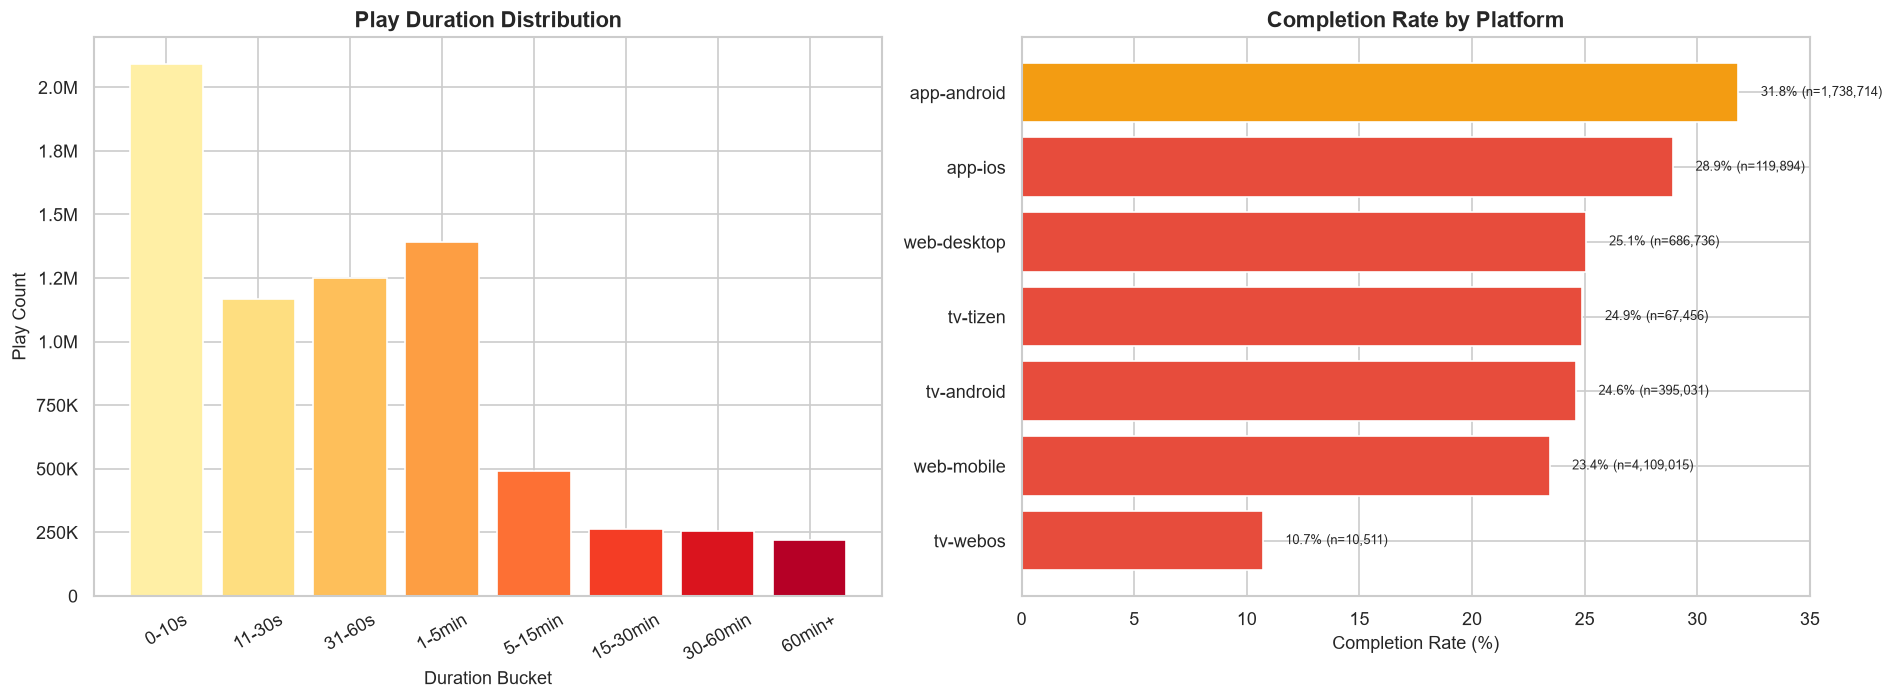

In [157]:
# Duration distribution and Completion by Platform
dur_pd = df_duration_dist.to_pandas().sort_values('bucket_order')
comp_pd = df_completion_by_platform.to_pandas()

# Convert types to avoid NAType issues
dur_pd['play_count'] = dur_pd['play_count'].astype(float)
comp_pd['completion_rate'] = comp_pd['completion_rate'].astype(float)
comp_pd['total_plays'] = comp_pd['total_plays'].astype(float)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Duration distribution
colors_dur = sns.color_palette('YlOrRd', n_colors=len(dur_pd))
ax1.bar(dur_pd['duration_bucket'], dur_pd['play_count'], color=colors_dur, edgecolor='white')
ax1.set_title('Play Duration Distribution', fontsize=13, fontweight='bold')
ax1.set_xlabel('Duration Bucket', fontsize=11)
ax1.set_ylabel('Play Count', fontsize=11)
ax1.tick_params(axis='x', rotation=30)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}K' if x >= 1e3 else f'{x:.0f}'))

# Completion rate by platform
comp_sorted = comp_pd.sort_values('completion_rate', ascending=True)
colors_comp = ['#e74c3c' if r < 30 else '#f39c12' if r < 50 else '#2ecc71' for r in comp_sorted['completion_rate']]
ax2.barh(comp_sorted['platform'], comp_sorted['completion_rate'], color=colors_comp, edgecolor='white')
ax2.set_title('Completion Rate by Platform', fontsize=13, fontweight='bold')
ax2.set_xlabel('Completion Rate (%)', fontsize=11)
ax2.set_xlim(0, 35)
for i, (v, t) in enumerate(zip(comp_sorted['completion_rate'], comp_sorted['total_plays'])):
    ax2.text(v + 1, i, f'{v:.1f}% (n={t:,.0f})', va='center', fontsize=8)

plt.tight_layout()
plt.show()

### Bitrate Analysis

* **Key Findings:** The **200-500 kbps** range is the most popular, accounting for **4.51M plays** with a **25.64%** completion rate and an average buffer duration of **45.9s**. The **0-200 kbps** range has **2.28M plays** with a **22.85%** completion rate.

In [158]:
%%bqsql df_bitrate
SELECT
  bitrate_range,
  COUNT(*) AS play_count,
  ROUND(AVG(play_duration), 1) AS avg_duration_sec,
  ROUND(AVG(buffer_duration), 2) AS avg_buffer_sec,
  ROUND(COUNTIF(completed = true) * 100.0 / NULLIF(COUNTIF(completed IS NOT NULL), 0), 2) AS completion_rate
FROM `bigquery-rahmalianto.practice.vidio_test_raw`
GROUP BY bitrate_range
ORDER BY play_count DESC

,bitrate_range,play_count,avg_duration_sec,avg_buffer_sec,completion_rate
0,200-500,4511326,528.6,45953.1,25.64
1,0-200,2280167,295.8,23.45,22.85
2,unknown,335864,0.0,65137.18,<NA>


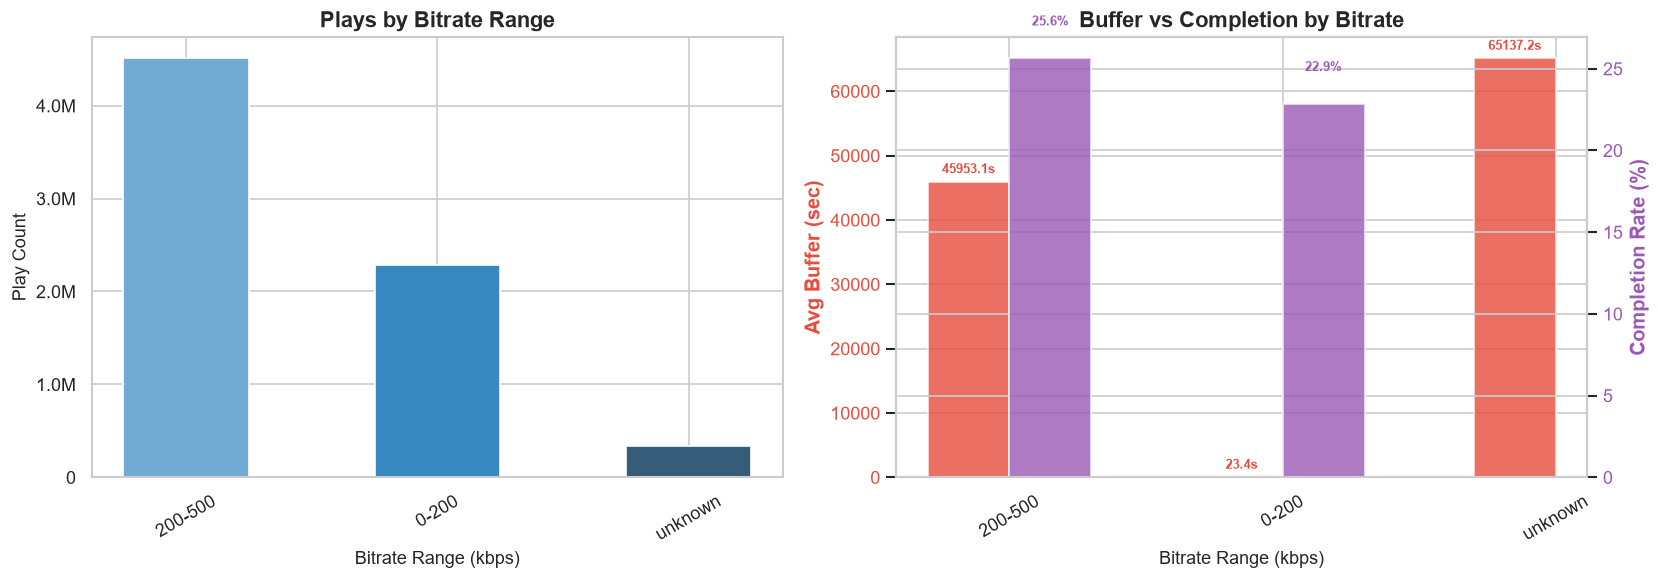

In [159]:
# Bitrate analysis chart
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

bitrate_pd = df_bitrate.to_pandas()

# Convert columns to float (this converts NAType to np.nan)
bitrate_pd['avg_buffer_sec'] = bitrate_pd['avg_buffer_sec'].astype(float)
bitrate_pd['completion_rate'] = bitrate_pd['completion_rate'].astype(float)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bitrate range distribution
colors_br = sns.color_palette('Blues_d', n_colors=len(bitrate_pd))
ax1.bar(bitrate_pd['bitrate_range'], bitrate_pd['play_count'],
        color=colors_br, edgecolor='white', width=0.5)
ax1.set_title('Plays by Bitrate Range', fontsize=13, fontweight='bold')
ax1.set_xlabel('Bitrate Range (kbps)', fontsize=11)
ax1.set_ylabel('Play Count', fontsize=11)
ax1.tick_params(axis='x', rotation=30)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}K' if x >= 1e3 else f'{x:.0f}'))

# Buffer vs Completion by bitrate (vertical bar chart with dual Y-axis)
x_indices = np.arange(len(bitrate_pd))
width = 0.3

ax_buf = ax2
ax_comp = ax_buf.twinx()

rects1 = ax_buf.bar(x_indices - width/2, bitrate_pd['avg_buffer_sec'], width,
                    label='Avg Buffer (s)', color='#e74c3c', alpha=0.8, edgecolor='white')
rects2 = ax_comp.bar(x_indices + width/2, bitrate_pd['completion_rate'], width,
                    label='Completion Rate (%)', color='#9b59b6', alpha=0.8, edgecolor='white')

ax_buf.set_ylabel('Avg Buffer (sec)', color='#e74c3c', fontweight='bold')
ax_buf.tick_params(axis='y', labelcolor='#e74c3c')
ax_comp.set_ylabel('Completion Rate (%)', color='#9b59b6', fontweight='bold')
ax_comp.tick_params(axis='y', labelcolor='#9b59b6')

# Add value labels
for i, val in enumerate(bitrate_pd['avg_buffer_sec']):
    if pd.notna(val):
        ax_buf.text(i - width/2, val + max(bitrate_pd['avg_buffer_sec'])*0.02, f'{val:.1f}s',
                    ha='center', fontsize=8, color='#e74c3c', fontweight='bold')
for i, val in enumerate(bitrate_pd['completion_rate']):
    if pd.notna(val):
        ax_comp.text(i + width/2, val + 2, f'{val:.1f}%',
                     ha='center', fontsize=8, color='#9b59b6', fontweight='bold')

ax_buf.set_xticks(x_indices)
ax_buf.set_xticklabels(bitrate_pd['bitrate_range'])
ax_buf.tick_params(axis='x', rotation=30)
ax_buf.set_title('Buffer vs Completion by Bitrate', fontsize=13, fontweight='bold')
ax_buf.set_xlabel('Bitrate Range (kbps)', fontsize=11)

plt.tight_layout()
plt.show()

## 6. Referrer & Traffic Analysis

* **Key Findings:** Traffic is split almost evenly between **direct** (3.51M plays) and **embedded** (3.62M plays) locations. However, embedded playbacks are overwhelmingly ad-supported (**98.3%** have ads), whereas direct playback has a more balanced split (**54.7%** with ads).

In [160]:
%%bqsql df_referrer
SELECT
  referrer_group,
  COUNT(*) AS play_count,
  ROUND(AVG(play_duration), 1) AS avg_duration_sec,
  ROUND(COUNTIF(completed = true) * 100.0 / NULLIF(COUNTIF(completed IS NOT NULL), 0), 2) AS completion_rate
FROM `bigquery-rahmalianto.practice.vidio_test_raw`
GROUP BY referrer_group
ORDER BY play_count DESC

,referrer_group,play_count,avg_duration_sec,completion_rate
0,others,2376439,834.8,26.35
1,kapanlagi,1041741,32.4,13.87
2,internal,760092,675.1,16.23
3,merdeka,736864,35.3,44.68
4,liputan6,704259,42.5,21.98
5,dream,431153,41.9,27.83
6,empty,386601,756.3,18.09
7,google,230561,596.3,7.21
8,bola,202961,34.2,22.26
9,bolanet,163687,29.6,29.01


In [161]:
%%bqsql df_playback_loc
SELECT
  playback_location,
  COUNT(*) AS play_count,
  ROUND(AVG(play_duration), 1) AS avg_duration_sec,
  ROUND(COUNTIF(completed = true) * 100.0 / NULLIF(COUNTIF(completed IS NOT NULL), 0), 2) AS completion_rate,
  COUNTIF(has_ad = true) AS plays_with_ad,
  COUNTIF(has_ad = false) AS plays_without_ad
FROM `bigquery-rahmalianto.practice.vidio_test_raw`
GROUP BY playback_location

,playback_location,play_count,avg_duration_sec,completion_rate,plays_with_ad,plays_without_ad
0,direct,3512100,831.9,23.62,1922452,1589648
1,embed,3615257,38.0,24.85,3555305,59952


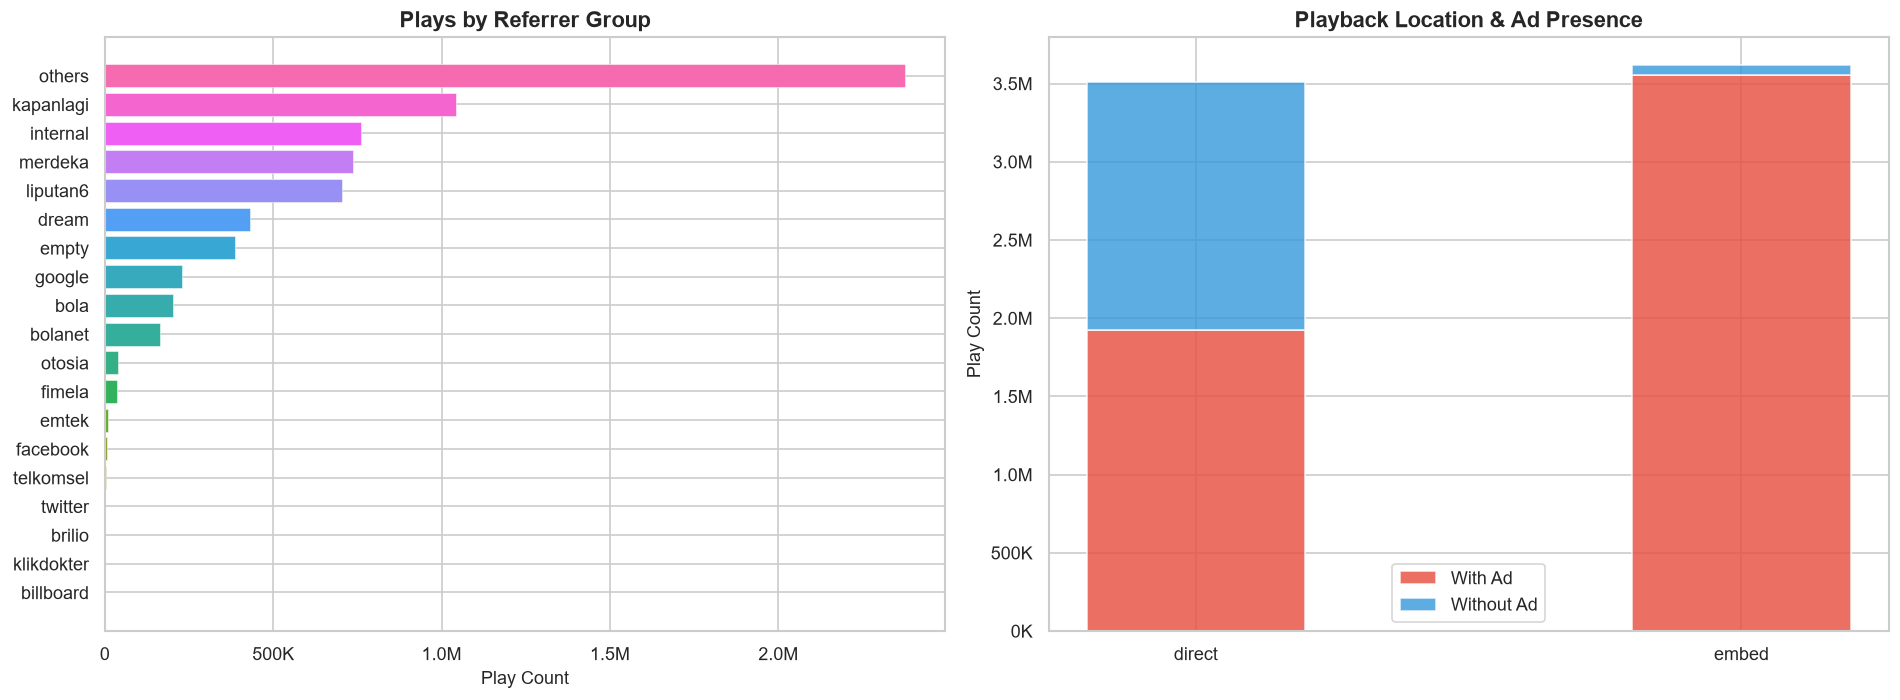

In [162]:
# Referrer group and playback location charts
ref_pd = df_referrer.to_pandas()
ploc_pd = df_playback_loc.to_pandas()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Referrer group
ref_sorted = ref_pd.sort_values('play_count', ascending=True)
colors_ref = sns.color_palette('husl', n_colors=len(ref_sorted))
ax1.barh(ref_sorted['referrer_group'], ref_sorted['play_count'],
         color=colors_ref, edgecolor='white', linewidth=0.3)
ax1.set_title('Plays by Referrer Group', fontsize=13, fontweight='bold')
ax1.set_xlabel('Play Count', fontsize=11)
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}K' if x >= 1e3 else f'{x:.0f}'))

# Playback location with stacked ad bar
bar_width = 0.4
x = range(len(ploc_pd))
ax2.bar(x, ploc_pd['plays_with_ad'], bar_width, label='With Ad', color='#e74c3c', alpha=0.8)
ax2.bar(x, ploc_pd['plays_without_ad'], bar_width, bottom=ploc_pd['plays_with_ad'],
        label='Without Ad', color='#3498db', alpha=0.8)
ax2.set_xticks(x)
ax2.set_xticklabels(ploc_pd['playback_location'])
ax2.set_title('Playback Location & Ad Presence', fontsize=13, fontweight='bold')
ax2.set_ylabel('Play Count', fontsize=11)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}K'))
ax2.legend()

plt.tight_layout()
plt.show()

### Autoplay & Login Analysis

* **Key Findings:** Logged-in users who watch via Autoplay show the longest average engagement (**1,562.5 seconds**), whereas anonymous users who watch manually have the shortest average duration (**65.5 seconds**).

In [163]:
%%bqsql df_autoplay_login
SELECT
  CASE WHEN autoplay THEN 'Autoplay' ELSE 'Manual' END AS play_mode,
  CASE WHEN is_login THEN 'Logged In' ELSE 'Anonymous' END AS login_status,
  COUNT(*) AS play_count,
  ROUND(AVG(play_duration), 1) AS avg_duration_sec,
  ROUND(COUNTIF(completed = true) * 100.0 / NULLIF(COUNTIF(completed IS NOT NULL), 0), 2) AS completion_rate
FROM `bigquery-rahmalianto.practice.vidio_test_raw`
WHERE autoplay IS NOT NULL
GROUP BY play_mode, login_status
ORDER BY play_count DESC

,play_mode,login_status,play_count,avg_duration_sec,completion_rate
0,Manual,Anonymous,3592474,65.5,23.4
1,Autoplay,Anonymous,444062,436.3,27.36
2,Autoplay,Logged In,438422,1562.5,31.94
3,Manual,Logged In,51387,731.8,20.54


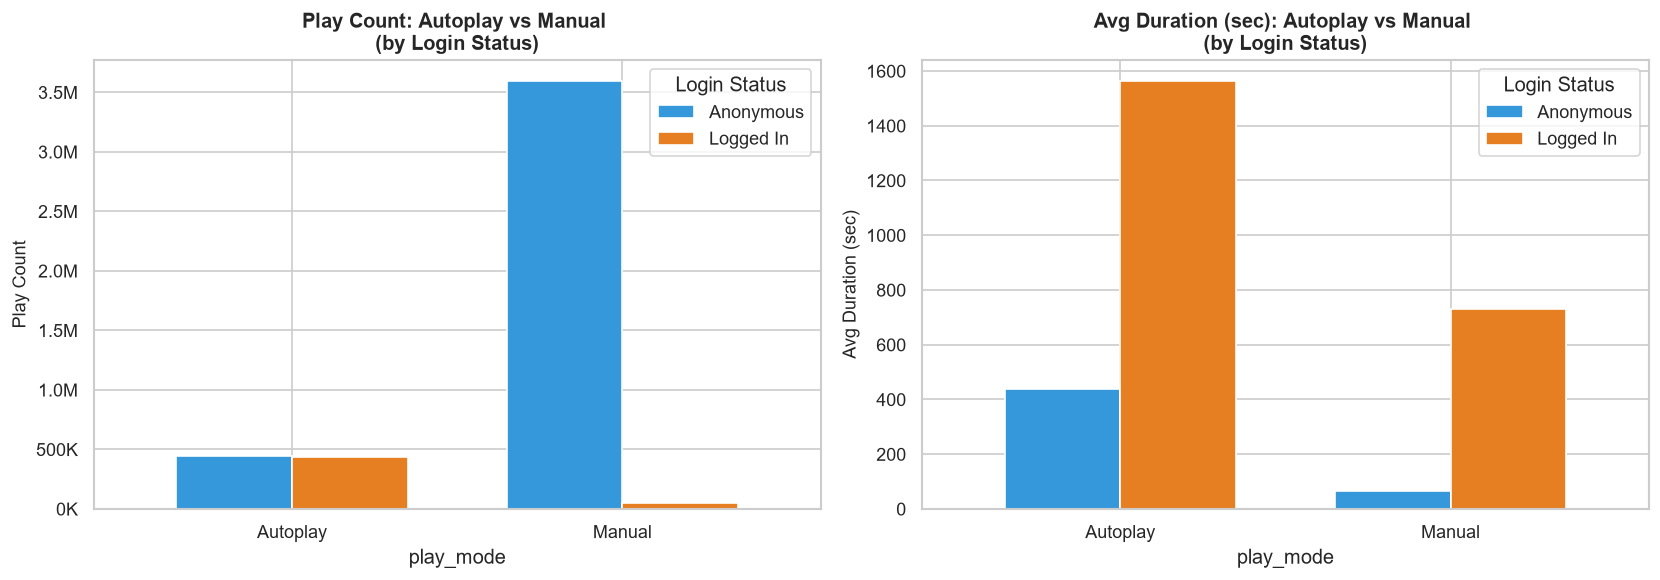

In [164]:
# Autoplay vs Manual grouped bar by login status
auto_pd = df_autoplay_login.to_pandas()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Grouped bar: play count by play mode and login status
pivot_count = auto_pd.pivot(index='play_mode', columns='login_status', values='play_count').fillna(0)
colors_al = ['#3498db', '#e67e22']
pivot_count.plot(kind='bar', ax=ax1, color=colors_al, edgecolor='white', width=0.7)
ax1.set_title('Play Count: Autoplay vs Manual \n(by Login Status)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Play Count', fontsize=11)
ax1.tick_params(axis='x', rotation=0)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}K'))
ax1.legend(title='Login Status')

# Grouped bar: avg duration
pivot_dur = auto_pd.pivot(index='play_mode', columns='login_status', values='avg_duration_sec').fillna(0)
pivot_dur.plot(kind='bar', ax=ax2, color=colors_al, edgecolor='white', width=0.7)
ax2.set_title('Avg Duration (sec): Autoplay vs Manual \n(by Login Status)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Avg Duration (sec)', fontsize=11)
ax2.tick_params(axis='x', rotation=0)
ax2.legend(title='Login Status')

plt.tight_layout()
plt.show()

## 7. Top Content

* **Key Findings:** **SCTV** is the most-watched livestreaming channel with **536,133 plays**, followed by **Indosiar** (**412,847 plays**). The top VOD title is a police news clip ("Video Polisi Tes Kandungan Sabu...") which achieved **102,097 plays**.

For film content, **Sinetron** is by far the leading genre with **222,202 plays** and a very high average watch duration of **1,783.2 seconds**.

In [165]:
%%bqsql df_top_titles
SELECT
  title,
  content_type,
  COUNT(*) AS play_count,
  COUNT(DISTINCT hash_watcher_id) AS unique_watchers,
  ROUND(AVG(play_duration), 1) AS avg_duration_sec
FROM `bigquery-rahmalianto.practice.vidio_test_raw`
GROUP BY title, content_type
ORDER BY play_count DESC
LIMIT 20

,title,content_type,play_count,unique_watchers,avg_duration_sec
0,SCTV,livestreaming,536133,301074,738.8
1,Indosiar,livestreaming,412847,227704,864.2
2,RCTI,livestreaming,330539,211017,852.8
3,TRANS TV,livestreaming,266154,151996,790.5
4,Trans7,livestreaming,209790,132367,722.3
5,GTV,livestreaming,150629,99527,612.2
6,MNC,livestreaming,132645,89351,533.8
7,Video Polisi Tes Kandungan Sabu Cair dalam Mai...,vod,102097,99104,30.8
8,TVOne,livestreaming,87808,59115,835.2
9,ANTV,livestreaming,85677,53882,800.1


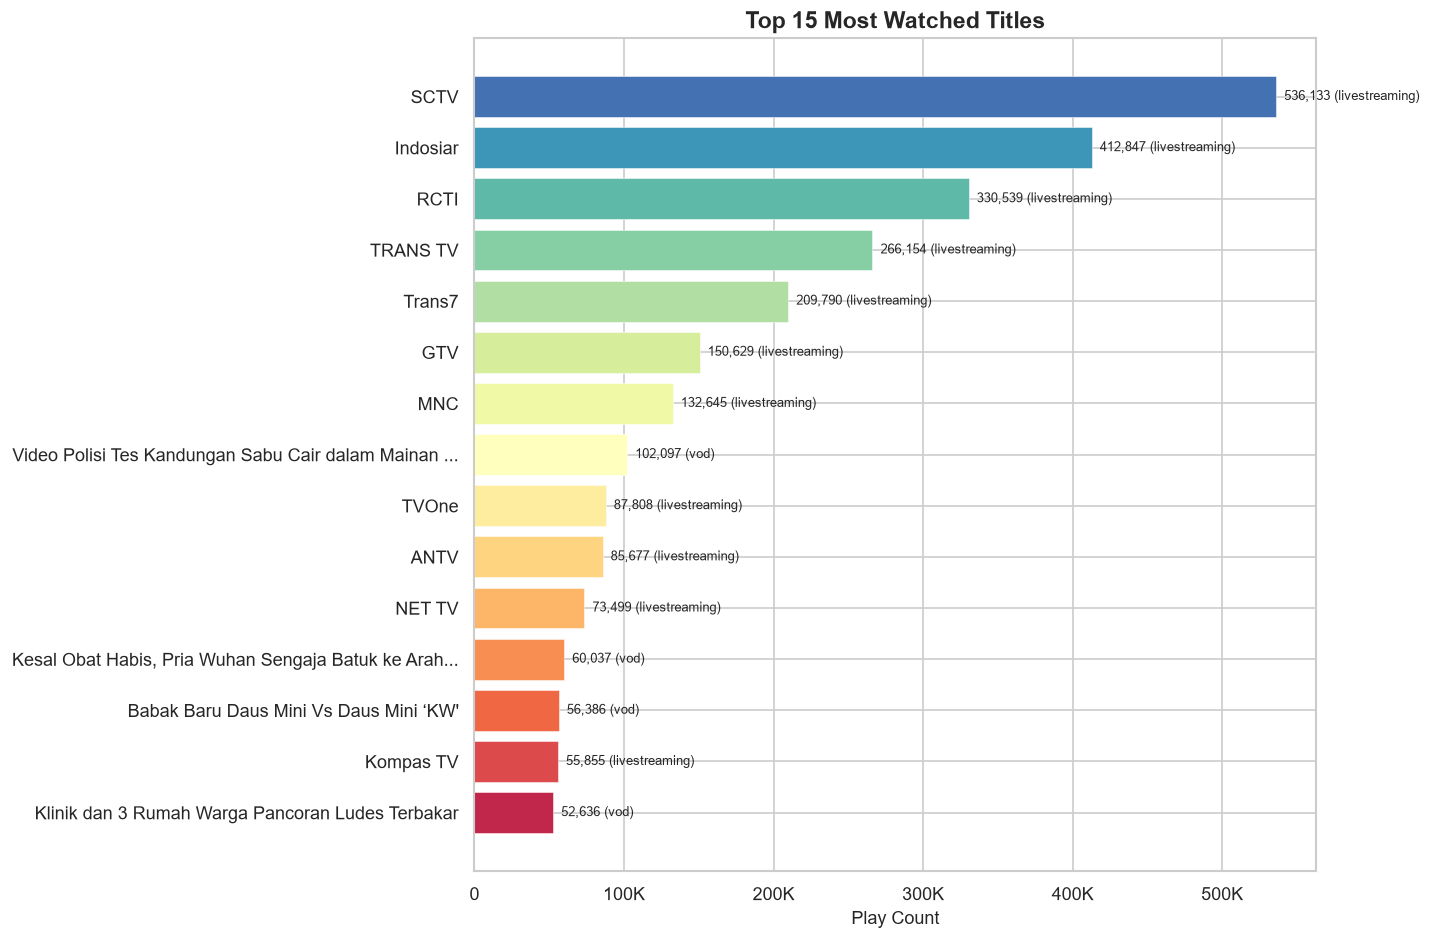

In [166]:
# Top 15 titles by play count
titles_pd = df_top_titles.to_pandas().head(15)

fig, ax = plt.subplots(figsize=(12, 8))

# Truncate long titles
titles_pd['title_short'] = titles_pd['title'].apply(lambda x: x[:50] + '...' if len(str(x)) > 50 else x)
titles_plot = titles_pd.sort_values('play_count')

colors_title = sns.color_palette('Spectral', n_colors=len(titles_plot))
ax.barh(titles_plot['title_short'], titles_plot['play_count'],
        color=colors_title, edgecolor='white', linewidth=0.3)
for i, (v, ct) in enumerate(zip(titles_plot['play_count'], titles_plot['content_type'])):
    ax.text(v + max(titles_plot['play_count'])*0.01, i,
            f'{v:,.0f} ({ct})', va='center', fontsize=8)

ax.set_title('Top 15 Most Watched Titles', fontsize=14, fontweight='bold')
ax.set_xlabel('Play Count', fontsize=11)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K' if x >= 1e3 else f'{x:.0f}'))
plt.tight_layout()
plt.show()

In [167]:
%%bqsql df_top_genres
WITH exploded_genres AS (
  SELECT
    TRIM(single_genre) AS genre_name_clean,
    play_duration
  FROM `bigquery-rahmalianto.practice.vidio_test_raw`,
  UNNEST(SPLIT(genre_name, ',')) AS single_genre
  WHERE genre_name IS NOT NULL AND TRIM(genre_name) != ''
)
SELECT
  genre_name_clean AS genre_name,
  COUNT(*) AS play_count,
  ROUND(AVG(play_duration), 1) AS avg_duration_sec
FROM exploded_genres
GROUP BY genre_name
ORDER BY play_count DESC
LIMIT 15

,genre_name,play_count,avg_duration_sec
0,Sinetron,222202,1783.2
1,Newly Added,68542,1094.1
2,Romance,57065,1045.6
3,Drama,50037,1700.1
4,Comedy,44680,853.7
5,Top 10 This Week,29299,1588.0
6,Popular,23738,1411.8
7,FTV,19426,1507.1
8,Korean Series,18283,1668.7
9,XL Home,11492,1645.9


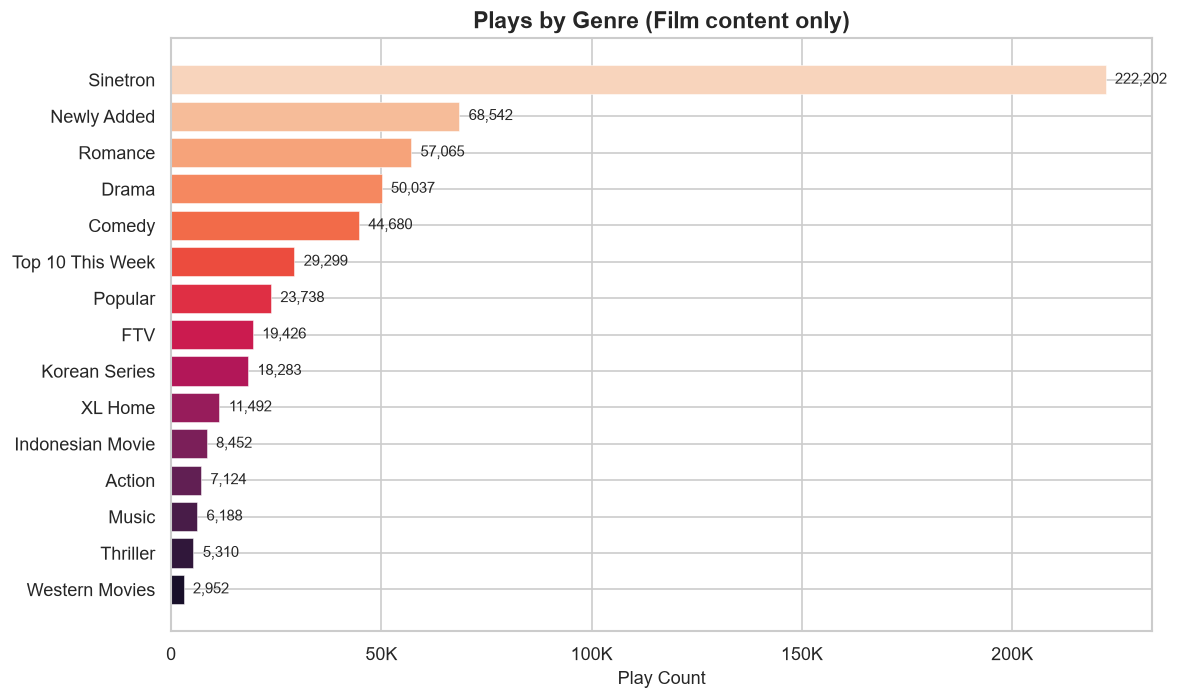

In [168]:
# Genre distribution
genre_pd = df_top_genres.to_pandas()

# Convert types to avoid NAType issues
genre_pd['play_count'] = genre_pd['play_count'].astype(float)
genre_pd = genre_pd[genre_pd['genre_name'] != 'N/A']  # Exclude N/A for cleaner view

fig, ax = plt.subplots(figsize=(10, 6))
genre_sorted = genre_pd.sort_values('play_count')
colors_genre = sns.color_palette('rocket', n_colors=len(genre_sorted))
ax.barh(genre_sorted['genre_name'], genre_sorted['play_count'],
        color=colors_genre, edgecolor='white', linewidth=0.3)
for i, v in enumerate(genre_sorted['play_count']):
    ax.text(v + max(genre_sorted['play_count'])*0.01, i,
            f'{v:,.0f}', va='center', fontsize=9)
ax.set_title('Plays by Genre (Film content only)', fontsize=14, fontweight='bold')
ax.set_xlabel('Play Count', fontsize=11)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K' if x >= 1e3 else f'{x:.0f}'))
plt.tight_layout()
plt.show()

## 8. User Behavior & Frequency Segmentation

Let's segment watchers based on dynamic quantiles of their play counts:
- **Heavy Watchers**: Top 10% (>90th percentile) of play counts (representing **277k watchers** who drive **30.5%** of all plays, with an average of **7.8 plays** per watcher).
- **Moderate Watchers**: 50th to 90th percentile of play counts (representing **727k watchers** driving **23.0%** of plays).
- **Occasional Watchers**: Bottom 50th percentile of play counts (representing **3.31M watchers** driving **46.5%** of plays, with an average of **1.0 play** per watcher).

* **Key Findings:** Heavy watchers not only play more content, but also watch longer on average (**782.4 seconds**) and have the highest completion rate (**26.72%**).

In [169]:
%%bqsql df_watcher_segments
WITH watcher_play_counts AS (
  SELECT
    hash_watcher_id,
    COUNT(*) AS play_count,
    AVG(play_duration) AS avg_duration,
    COUNTIF(completed = true) * 100.0 / NULLIF(COUNTIF(completed IS NOT NULL), 0) AS completion_rate
  FROM `bigquery-rahmalianto.practice.vidio_test_raw`
  WHERE hash_watcher_id IS NOT NULL
  GROUP BY hash_watcher_id
),
percentiles AS (
  SELECT
    percentiles[OFFSET(50)] AS p50,
    percentiles[OFFSET(90)] AS p90
  FROM (
    SELECT APPROX_QUANTILES(play_count, 100) AS percentiles
    FROM watcher_play_counts
  )
),
watcher_segments AS (
  SELECT
    w.*,
    CASE
      WHEN w.play_count > p.p90 THEN 'Heavy (>90th pct)'
      WHEN w.play_count > p.p50 THEN 'Moderate (50th-90th pct)'
      ELSE 'Occasional (<=50th pct)'
    END AS watcher_segment
  FROM watcher_play_counts w
  CROSS JOIN percentiles p
)
SELECT
  watcher_segment,
  COUNT(DISTINCT hash_watcher_id) AS watcher_count,
  SUM(play_count) AS total_plays,
  ROUND(AVG(play_count), 1) AS avg_plays_per_watcher,
  ROUND(AVG(avg_duration), 1) AS avg_duration_sec,
  ROUND(AVG(completion_rate), 2) AS completion_rate_pct
FROM watcher_segments
GROUP BY watcher_segment
ORDER BY watcher_segment

,watcher_segment,watcher_count,total_plays,avg_plays_per_watcher,avg_duration_sec,completion_rate_pct
0,Heavy (>90th pct),277210,2173564,7.8,782.4,26.72
1,Moderate (50th-90th pct),727283,1641805,2.3,431.7,25.5
2,Occasional (<=50th pct),3311988,3311988,1.0,187.7,23.76


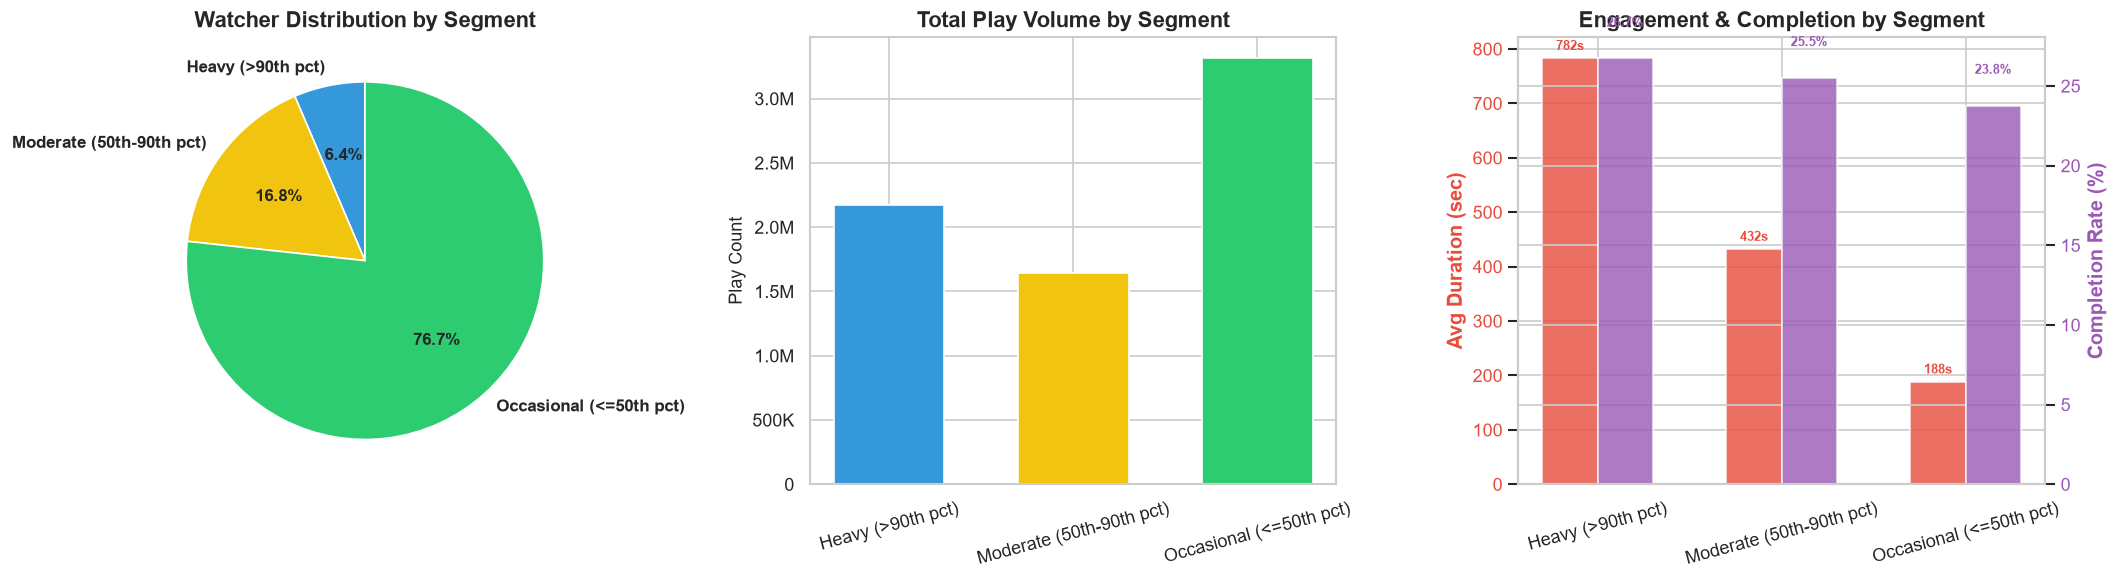

In [170]:
# Visualization of Watcher Segments
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

segments_pd = df_watcher_segments.to_pandas()

# Convert to standard types to avoid NAType issues
segments_pd['watcher_count'] = segments_pd['watcher_count'].astype(float)
segments_pd['total_plays'] = segments_pd['total_plays'].astype(float)
segments_pd['avg_plays_per_watcher'] = segments_pd['avg_plays_per_watcher'].astype(float)
segments_pd['avg_duration_sec'] = segments_pd['avg_duration_sec'].astype(float)
segments_pd['completion_rate_pct'] = segments_pd['completion_rate_pct'].astype(float)

# Sort for consistent plotting (Occasional -> Moderate -> Heavy)
segments_pd = segments_pd.sort_values('watcher_segment')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors_seg = ['#3498db', '#f1c40f', '#2ecc71']

# Subplot 1: Watchers distribution
axes[0].pie(segments_pd['watcher_count'], labels=segments_pd['watcher_segment'],
            autopct='%1.1f%%', colors=colors_seg, startangle=90,
            textprops={'fontsize': 10, 'weight': 'bold'})
axes[0].set_title('Watcher Distribution by Segment', fontsize=13, fontweight='bold')

# Subplot 2: Play volume contribution
axes[1].bar(segments_pd['watcher_segment'], segments_pd['total_plays'],
            color=colors_seg, edgecolor='white', width=0.6)
axes[1].set_title('Total Play Volume by Segment', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Play Count', fontsize=11)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}K' if x >= 1e3 else f'{x:.0f}'))
axes[1].tick_params(axis='x', rotation=15)

# Subplot 3: Dual Y-axis for Avg Duration & Completion Rate
x_indices = np.arange(len(segments_pd))
width = 0.3

ax_dur = axes[2]
ax_comp = ax_dur.twinx()

rects1 = ax_dur.bar(x_indices - width/2, segments_pd['avg_duration_sec'], width,
                    label='Avg Duration', color='#e74c3c', alpha=0.8, edgecolor='white')
rects2 = ax_comp.bar(x_indices + width/2, segments_pd['completion_rate_pct'], width,
                    label='Completion Rate', color='#9b59b6', alpha=0.8, edgecolor='white')

ax_dur.set_ylabel('Avg Duration (sec)', color='#e74c3c', fontweight='bold')
ax_dur.tick_params(axis='y', labelcolor='#e74c3c')
ax_comp.set_ylabel('Completion Rate (%)', color='#9b59b6', fontweight='bold')
ax_comp.tick_params(axis='y', labelcolor='#9b59b6')

ax_dur.set_xticks(x_indices)
ax_dur.set_xticklabels(segments_pd['watcher_segment'])
axes[2].set_title('Engagement & Completion by Segment', fontsize=13, fontweight='bold')
axes[2].tick_params(axis='x', rotation=15)

# Add value labels for Subplot 3
for i, val in enumerate(segments_pd['avg_duration_sec']):
    ax_dur.text(i - width/2, val + max(segments_pd['avg_duration_sec'])*0.02, f'{val:.0f}s', 
                 ha='center', fontsize=8, color='#e74c3c', fontweight='bold')
for i, val in enumerate(segments_pd['completion_rate_pct']):
    ax_comp.text(i + width/2, val + 2, f'{val:.1f}%', 
                 ha='center', fontsize=8, color='#9b59b6', fontweight='bold')

plt.tight_layout()
plt.show()

## 9. Sessionization & Journey Analysis

We analyze user behavior at the session level by grouping play events by `hash_visit_id` (session ID). This shows us how many plays occur within a single session and the distribution of total session watch time.

* **Key Findings:** Over **92%** of all user sessions consist of only a **single play**, indicating very low session depth. Furthermore, total watch time per session is heavily skewed towards short durations, with the vast majority of sessions lasting **less than 1 minute**.

In [171]:
%%bqsql df_session_summary
WITH session_metrics AS (
  SELECT
    hash_visit_id,
    COUNT(*) AS plays_count,
    SUM(play_duration) AS total_duration_sec
  FROM `bigquery-rahmalianto.practice.vidio_test_raw`
  WHERE hash_visit_id IS NOT NULL
  GROUP BY hash_visit_id
)
SELECT
  plays_count,
  CASE
    WHEN total_duration_sec <= 60 THEN '0-1 min'
    WHEN total_duration_sec <= 300 THEN '1-5 min'
    WHEN total_duration_sec <= 900 THEN '5-15 min'
    WHEN total_duration_sec <= 1800 THEN '15-30 min'
    WHEN total_duration_sec <= 3600 THEN '30-60 min'
    ELSE '60 min+'
  END AS duration_bucket,
  CASE
    WHEN total_duration_sec <= 60 THEN 1
    WHEN total_duration_sec <= 300 THEN 2
    WHEN total_duration_sec <= 900 THEN 3
    WHEN total_duration_sec <= 1800 THEN 4
    WHEN total_duration_sec <= 3600 THEN 5
    ELSE 6
  END AS bucket_order,
  COUNT(*) AS session_count
FROM session_metrics
GROUP BY plays_count, duration_bucket, bucket_order

,plays_count,duration_bucket,bucket_order,session_count
0,1,0-1 min,1,3613837
1,6,30-60 min,5,728
2,6,60 min+,6,834
3,5,15-30 min,4,2076
4,3,30-60 min,5,9769
5,12,15-30 min,4,37
6,3,1-5 min,2,28303
7,2,0-1 min,1,143071
8,5,5-15 min,3,3035
9,3,0-1 min,1,18724


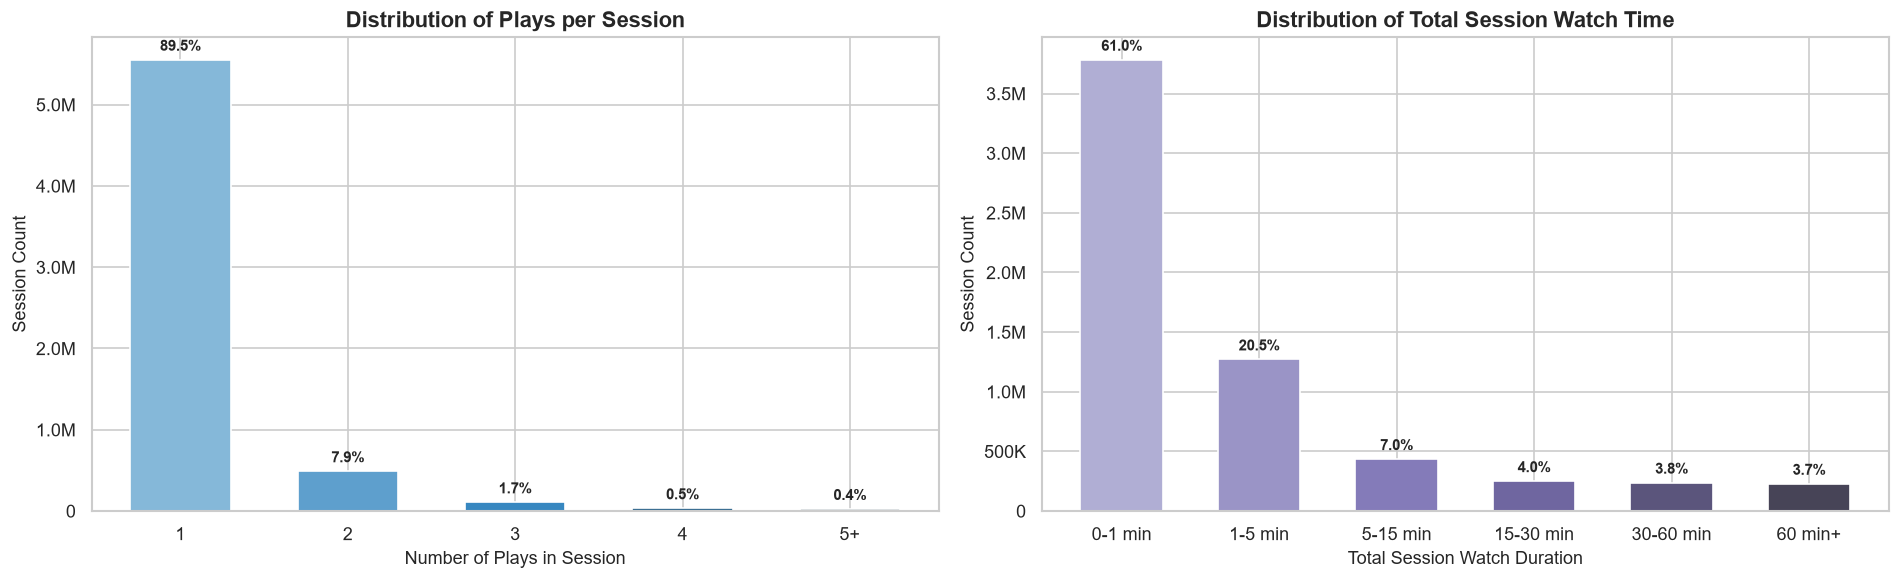

In [172]:
# Plot Sessionization Metrics
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sess_pd = df_session_summary.to_pandas()

# Convert types to avoid NAType issues
sess_pd['plays_count'] = sess_pd['plays_count'].astype(float)
sess_pd['session_count'] = sess_pd['session_count'].astype(float)
sess_pd['bucket_order'] = sess_pd['bucket_order'].astype(float)

# 1. Aggregation for plays per session (group 5+ plays)
plays_dist = sess_pd.groupby('plays_count')['session_count'].sum().reset_index()
plays_dist['plays_label'] = plays_dist['plays_count'].apply(lambda x: f'{int(x)}' if x < 5 else '5+')
plays_grouped = plays_dist.groupby('plays_label')['session_count'].sum().reset_index()
plays_grouped['sort_order'] = plays_grouped['plays_label'].map({'1': 1, '2': 2, '3': 3, '4': 4, '5+': 5})
plays_grouped = plays_grouped.sort_values('sort_order')

# 2. Aggregation for session duration
dur_dist = sess_pd.groupby(['duration_bucket', 'bucket_order'])['session_count'].sum().reset_index()
dur_dist = dur_dist.sort_values('bucket_order')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Subplot 1: Plays per Session
colors_plays = sns.color_palette('Blues_d', n_colors=len(plays_grouped))
ax1.bar(plays_grouped['plays_label'], plays_grouped['session_count'], color=colors_plays, edgecolor='white', width=0.6)
ax1.set_title('Distribution of Plays per Session', fontsize=13, fontweight='bold')
ax1.set_xlabel('Number of Plays in Session', fontsize=11)
ax1.set_ylabel('Session Count', fontsize=11)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}K' if x >= 1e3 else f'{x:.0f}'))
for i, v in enumerate(plays_grouped['session_count']):
    pct = v / plays_grouped['session_count'].sum() * 100
    ax1.text(i, v + max(plays_grouped['session_count'])*0.02, f'{pct:.1f}%', ha='center', fontsize=9, fontweight='bold')

# Subplot 2: Total Session Watch Time
colors_dur = sns.color_palette('Purples_d', n_colors=len(dur_dist))
ax2.bar(dur_dist['duration_bucket'], dur_dist['session_count'], color=colors_dur, edgecolor='white', width=0.6)
ax2.set_title('Distribution of Total Session Watch Time', fontsize=13, fontweight='bold')
ax2.set_xlabel('Total Session Watch Duration', fontsize=11)
ax2.set_ylabel('Session Count', fontsize=11)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}K' if x >= 1e3 else f'{x:.0f}'))
for i, v in enumerate(dur_dist['session_count']):
    pct = v / dur_dist['session_count'].sum() * 100
    ax2.text(i, v + max(dur_dist['session_count'])*0.02, f'{pct:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

## 10. Autoplay & Ad Engagement Impact (Bounce Analysis)

We study the impact of autoplay and ads (`has_ad`) on play engagement, specifically focusing on **bounce plays** (defined as play duration <= 10 seconds). This helps us see if autoplay drives high bounce rates and how ad presence affects initial user retention.

* **Key Findings:** The presence of ads increases the bounce rate significantly (from **16.2%** to **32.6%** when Autoplay is OFF). Autoplay ON has a high baseline bounce rate of **29.9%** (no ads), which rises to **35.8%** when ads are present.

In [173]:
%%bqsql df_autoplay_ad_bounce
SELECT
  IFNULL(autoplay, false) AS autoplay_status,
  IFNULL(has_ad, false) AS ad_status,
  COUNT(*) AS total_plays,
  COUNTIF(play_duration <= 10) AS bounce_plays,
  ROUND(COUNTIF(play_duration <= 10) * 100.0 / COUNT(*), 2) AS bounce_rate_pct,
  ROUND(COUNTIF(completed = true) * 100.0 / NULLIF(COUNTIF(completed IS NOT NULL), 0), 2) AS completion_rate_pct
FROM `bigquery-rahmalianto.practice.vidio_test_raw`
GROUP BY autoplay_status, ad_status
ORDER BY autoplay_status, ad_status

,autoplay_status,ad_status,total_plays,bounce_plays,bounce_rate_pct,completion_rate_pct
0,False,False,1559622,252698,16.2,21.83
1,False,True,4685251,1528894,32.63,23.39
2,True,False,89978,26959,29.96,28.86
3,True,True,792506,283766,35.81,29.72


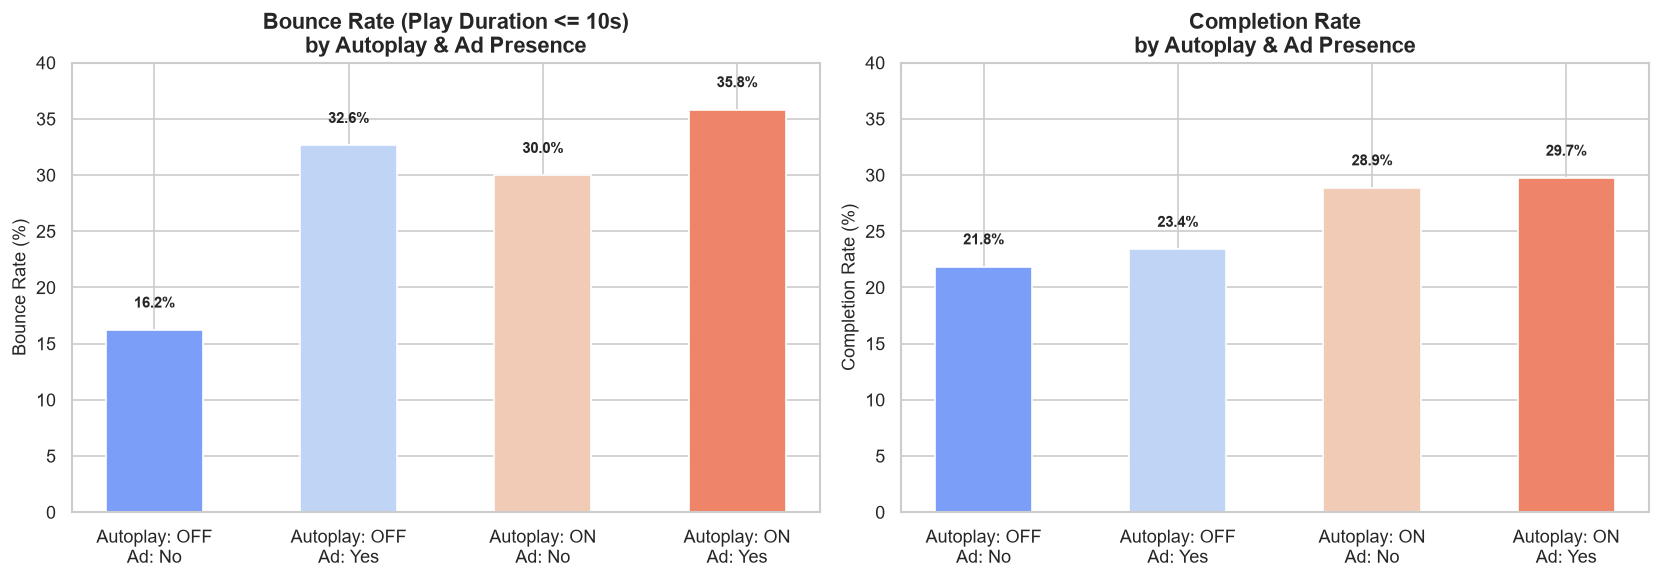

In [174]:
# Plot Autoplay & Ad Bounce Impact
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

bounce_pd = df_autoplay_ad_bounce.to_pandas()

# Convert types to avoid NAType issues
bounce_pd['autoplay_status'] = bounce_pd['autoplay_status'].astype(bool)
bounce_pd['ad_status'] = bounce_pd['ad_status'].astype(bool)
bounce_pd['total_plays'] = bounce_pd['total_plays'].astype(float)
bounce_pd['bounce_plays'] = bounce_pd['bounce_plays'].astype(float)
bounce_pd['bounce_rate_pct'] = bounce_pd['bounce_rate_pct'].astype(float)
bounce_pd['completion_rate_pct'] = bounce_pd['completion_rate_pct'].astype(float)

# Create combination labels for easier plotting
bounce_pd['combination'] = bounce_pd.apply(
    lambda r: f"Autoplay: {'ON' if r['autoplay_status'] else 'OFF'}\nAd: {'Yes' if r['ad_status'] else 'No'}", axis=1
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
colors_comb = sns.color_palette('coolwarm', n_colors=len(bounce_pd))

# Subplot 1: Bounce Rate
ax1.bar(bounce_pd['combination'], bounce_pd['bounce_rate_pct'], color=colors_comb, edgecolor='white', width=0.5)
ax1.set_title('Bounce Rate (Play Duration <= 10s)\nby Autoplay & Ad Presence', fontsize=13, fontweight='bold')
ax1.set_ylabel('Bounce Rate (%)', fontsize=11)
ax1.set_ylim(0, 40)
for i, v in enumerate(bounce_pd['bounce_rate_pct']):
    ax1.text(i, v + 2, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')

# Subplot 2: Completion Rate
ax2.bar(bounce_pd['combination'], bounce_pd['completion_rate_pct'], color=colors_comb, edgecolor='white', width=0.5)
ax2.set_title('Completion Rate\nby Autoplay & Ad Presence', fontsize=13, fontweight='bold')
ax2.set_ylabel('Completion Rate (%)', fontsize=11)
ax2.set_ylim(0, 40)
for i, v in enumerate(bounce_pd['completion_rate_pct']):
    ax2.text(i, v + 2, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

## 11. App/Device Specific Performance Heatmap

We analyze the top combinations of `app_name` and `os_name` to spot performance and user experience anomalies, visualizing their average buffer duration and completion rates.

* **Key Findings:** The **Vidio app on Android** is the most common combination, with **3.86M plays** (avg buffer: **9.48s**, completion rate: **23.13%**). We observe massive buffering anomalies for the Vidio app on **Unknown OS** (avg buffer: **101,533s**), which indicates anomalous values in the underlying dataset or tracking issues.

In [175]:
%%bqsql df_device_anomalies
WITH top_devices AS (
  SELECT
    IFNULL(NULLIF(app_name, ''), 'Unknown App') AS app_name_clean,
    IFNULL(NULLIF(os_name, ''), 'Unknown OS') AS os_name_clean,
    COUNT(*) AS play_count
  FROM `bigquery-rahmalianto.practice.vidio_test_raw`
  GROUP BY app_name_clean, os_name_clean
  ORDER BY play_count DESC
  LIMIT 15
)
SELECT
  a.app_name_clean,
  a.os_name_clean,
  COUNT(*) AS total_plays,
  ROUND(AVG(a.buffer_duration), 2) AS avg_buffer_sec,
  ROUND(COUNTIF(a.completed = true) * 100.0 / NULLIF(COUNTIF(a.completed IS NOT NULL), 0), 2) AS completion_rate_pct
FROM (
  SELECT
    IFNULL(NULLIF(app_name, ''), 'Unknown App') AS app_name_clean,
    IFNULL(NULLIF(os_name, ''), 'Unknown OS') AS os_name_clean,
    buffer_duration,
    completed
  FROM `bigquery-rahmalianto.practice.vidio_test_raw`
) a
INNER JOIN top_devices t
  ON a.app_name_clean = t.app_name_clean AND a.os_name_clean = t.os_name_clean
GROUP BY a.app_name_clean, a.os_name_clean
ORDER BY total_plays DESC

,app_name_clean,os_name_clean,total_plays,avg_buffer_sec,completion_rate_pct
0,vidio,Android,3859925,9.48,23.13
1,vidio,Unknown OS,2256463,101533.41,31.46
2,vidio,Windows,635241,51.76,25.49
3,vidio,iOS,254846,33.54,28.28
4,vidio,REL,73833,706.51,25.14
5,vidio,Mac OS X,28946,106.51,23.22
6,vidio,Linux,10333,18.46,14.29
7,vidio,Tizen,2410,4.33,6.08
8,vidio,Ubuntu,1513,52.58,23.23
9,vidio,Other,1149,76.76,8.15


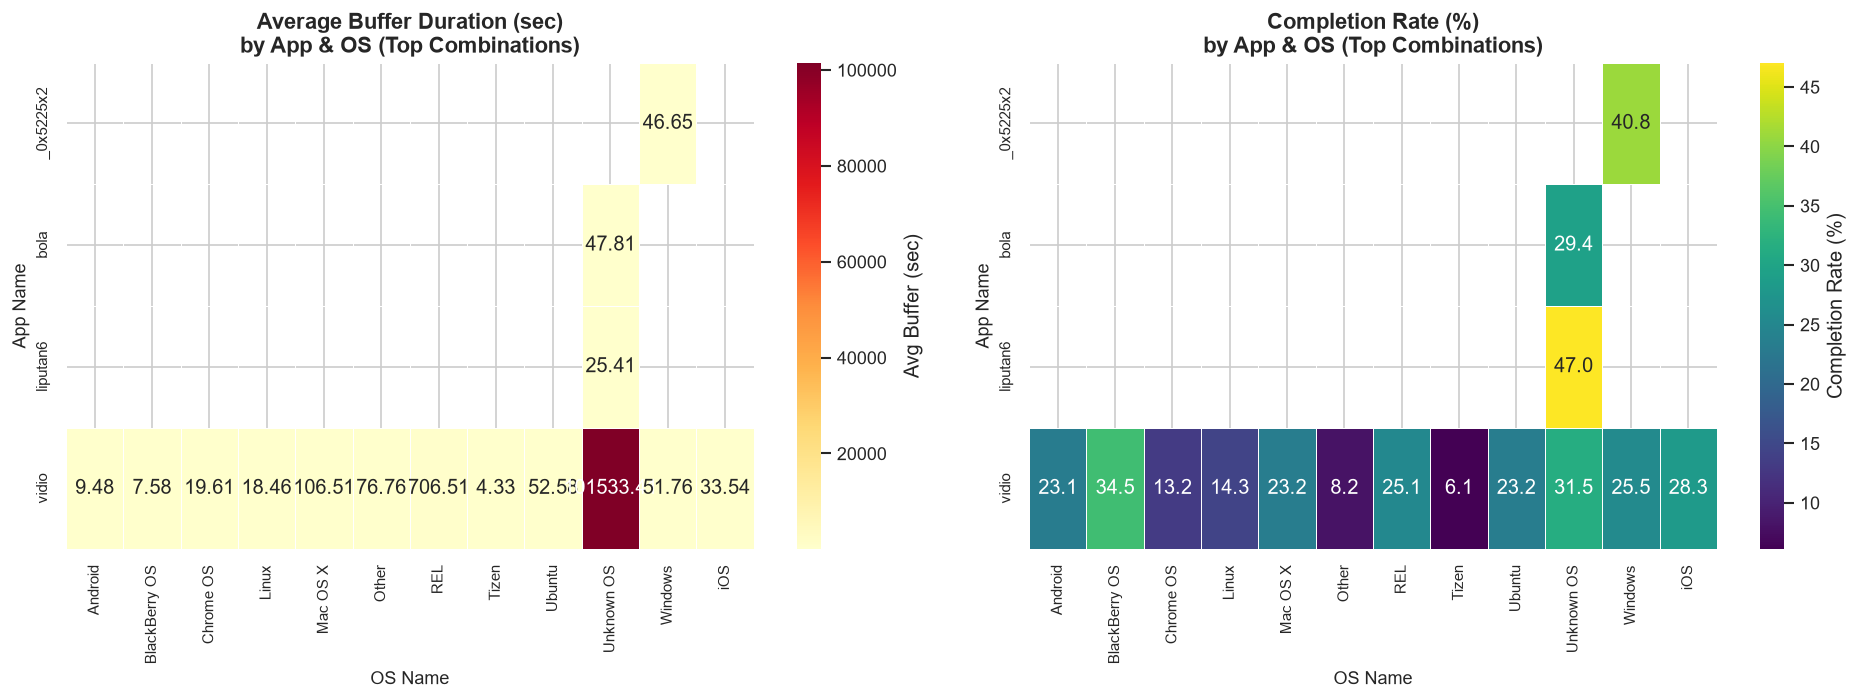

In [176]:
# Plot App/OS Performance Heatmaps
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

dev_pd = df_device_anomalies.to_pandas()

# Convert to standard float to avoid NAType plotting issues
dev_pd['avg_buffer_sec'] = dev_pd['avg_buffer_sec'].astype(float)
dev_pd['completion_rate_pct'] = dev_pd['completion_rate_pct'].astype(float)

# Pivot the data for the heatmap matrices
buffer_pivot = dev_pd.pivot(index='app_name_clean', columns='os_name_clean', values='avg_buffer_sec')
comp_pivot = dev_pd.pivot(index='app_name_clean', columns='os_name_clean', values='completion_rate_pct')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap 1: Buffer Duration (YlOrRd colormap indicates delay/stress)
sns.heatmap(buffer_pivot, annot=True, fmt=".2f", cmap="YlOrRd", ax=ax1, 
            cbar_kws={'label': 'Avg Buffer (sec)'}, linewidths=0.5, linecolor='white')
ax1.set_title('Average Buffer Duration (sec)\nby App & OS (Top Combinations)', fontsize=13, fontweight='bold')
ax1.set_xlabel('OS Name', fontsize=11)
ax1.set_ylabel('App Name', fontsize=11)
ax1.tick_params(axis='both', which='major', labelsize=9)

# Heatmap 2: Completion Rate (Viridis colormap indicates percentage achievement)
sns.heatmap(comp_pivot, annot=True, fmt=".1f", cmap="viridis", ax=ax2, 
            cbar_kws={'label': 'Completion Rate (%)'}, linewidths=0.5, linecolor='white')
ax2.set_title('Completion Rate (%)\nby App & OS (Top Combinations)', fontsize=13, fontweight='bold')
ax2.set_xlabel('OS Name', fontsize=11)
ax2.set_ylabel('App Name', fontsize=11)
ax2.tick_params(axis='both', which='major', labelsize=9)

plt.tight_layout()
plt.show()

## Summary

### Key Findings

- **Data Scale**: 7.13M plays, 4.32M unique watchers, and 105k unique titles. 22.9% of plays are by logged-in users, 77.1% anonymous.
- **Traffic Patterns**: Daily plays remain stable (400k–550k), peaking on Wed, Feb 12 (549k plays). Evening prime-time peaks at 6 PM–9 PM WIB, with Sunday being the busiest day (1.29M plays) and Friday the quietest (865k plays).
- **Platforms**: Mobile-web dominates plays (57.7%), followed by the Android app (24.4%) and desktop-web (9.6%).
- **Content & Tiers**: VOD represents 63.1% of plays, while livestreaming (36.5%) drives 3x longer watch times (733.7s vs 245s). Free tier drives 99.1% of plays, but Premium tier (0.9%) shows exceptional loyalty (1,404s average view time, 33.1% completion rate).
- **Engagement & Sessions**: Watch time is highly skewed: 29.4% bounce within 10s and 63% watch under 1 minute. 92% of sessions consist of a single play. Autoplay ON combined with ads leads to a high bounce rate of 35.8%.

---

### Strategic Recommendations

1. **Optimize Mobile-Web Player**: Improve buffering and UI on mobile-web (57.7% plays) to bridge the completion rate gap with the Android app (23.4% vs 31.8%).
2. **Convert Heavy Watchers**: Target Heavy Watchers (top 10% of users driving 30.5% of plays) with subscription campaigns to convert them to the highly-engaged Premium tier.
3. **Refine Autoplay Ad Strategy**: Mitigate the 35.8% autoplay ad bounce rate by replacing pre-roll ads on auto-played content with non-intrusive overlay or mid-roll ads.
4. **Improve Session Depth**: Introduce "Up Next" countdowns and end-screen recommendations to keep users watching beyond a single video (currently 92% of sessions).
5. **Scale Infrastructure**: Plan server maintenance during low-traffic hours (2 AM–4 AM WIB) and scale capacity for evening peak hours (6 PM–9 PM WIB).
6. **Investigate Buffering Anomalies**: Debug logging anomalies on the Android app (9.48s avg buffer) and the extreme buffering values recorded on Unknown OS.